# Control vs SDV: latent-variable causal models
This notebook applies the existing Case 2 and Case 4 estimators to paired CONN 19-ROI BOLD time series. Outputs are descriptive; no biological causal claims or inferential tests are made.

## 1. Setup

In [ ]:
from pathlib import Path
import os, sys, numpy as np
from IPython.display import Image, display
ROOT=Path.cwd().parent if Path.cwd().name=='notebooks' else Path.cwd()
sys.path.insert(0,str(ROOT/'src'))
from causal_opt.fmri import *
from causal_opt.fmri_inference import *
from causal_opt.methods.static_latent import fit_static_latent
from causal_opt.methods.dynamic_latent import fit_dynamic_latent
DATA=ROOT.parent/'fmri_connectivity'/'data'/'mat_files'/'rs_sessions_r03_healthy'
SESSION1=Path(os.getenv('FMRI_SESSION1_ZIP',DATA/'roi_rs_sessions_Session1.zip'))
SESSION2=Path(os.getenv('FMRI_SESSION2_ZIP',DATA/'roi_rs_sessions_Session2.zip'))
OUTPUT=ROOT/'results'/'fmri_notebook'; OUTPUT.mkdir(parents=True,exist_ok=True)
SEED=1; K=2; P=1; EDGE_THRESHOLD=.3
MAX_OUTER=100; INNER_MAX=None; H_TOL = 1e-8
STATIC=dict(k=K,lambda_w=.1,lambda_latent=.1,w_threshold=EDGE_THRESHOLD,random_state=SEED,max_outer_iter=MAX_OUTER,inner_max_iter=INNER_MAX, h_tol=H_TOL)
DYNAMIC=dict(k=K,lambda_0=.1,lambda_lag=.05,lambda_latent=.02,w0_threshold=EDGE_THRESHOLD,wlag_threshold=EDGE_THRESHOLD,random_state=SEED,max_outer_iter=MAX_OUTER,inner_max_iter=INNER_MAX, h_tol=H_TOL)
DISPLAY=tuple(f'BN19-{i:02d}' for i in range(1,20))
DISPLAY=BLADDER19_LABELS

patient_sex = {
    2: 'Female',
    3: 'Female',
    4: 'Female',
    5: 'Female',
    6: 'Female',
    7: 'Male',
    8: 'Male',
    9: 'Female',
    10: 'Male',
    11: 'Male',
    12: 'Male',
    13: 'Female',
    14: 'Male',
    15: 'Female',
    16: 'Male',
    17: 'Female',
    18: 'Male',
    19: 'Female',
    20: 'Male',
}

## 2. Load 19-ROI fMRI data

In [2]:
control,sdv=load_fmri_state_data(SESSION1,SESSION2)
print(data_summary(control,'control / empty bladder'))
print(data_summary(sdv,'full bladder / SDV'))
print(control.subject_ids); print(control.roi_names)
X_control=build_static_fmri_matrix(control); X_sdv=build_static_fmri_matrix(sdv)
print('pooled:',X_control.shape,X_sdv.shape)

{'state': 'control / empty bladder', 'subjects': 19, 'rois': 19, 'T_min': 168, 'T_median': 192.0, 'T_max': 194, 'pooled_rows': 3627}
{'state': 'full bladder / SDV', 'subjects': 19, 'rois': 19, 'T_min': 168, 'T_median': 192.0, 'T_max': 196, 'pooled_rows': 3628}
('Subject001', 'Subject002', 'Subject003', 'Subject004', 'Subject005', 'Subject006', 'Subject007', 'Subject008', 'Subject009', 'Subject010', 'Subject011', 'Subject012', 'Subject013', 'Subject014', 'Subject015', 'Subject016', 'Subject017', 'Subject018', 'Subject019')
('Bladder Network 19.cluster001', 'Bladder Network 19.cluster002', 'Bladder Network 19.cluster003', 'Bladder Network 19.cluster004', 'Bladder Network 19.cluster005', 'Bladder Network 19.cluster006', 'Bladder Network 19.cluster007', 'Bladder Network 19.cluster008', 'Bladder Network 19.cluster009', 'Bladder Network 19.cluster010', 'Bladder Network 19.cluster011', 'Bladder Network 19.cluster012', 'Bladder Network 19.cluster013', 'Bladder Network 19.cluster014', 'Bladder 

## 3. Case 2 — static latent-confounded causal model

In [4]:
static_control=fit_static_latent(X_control,**STATIC)
static_sdv=fit_static_latent(X_sdv,**STATIC)
print(static_control.diagnostics); print(static_sdv.diagnostics)

{'objective': 38.11556204914374, 'primal_objective': 38.11442475123746, 'fit_loss': 36.96891143170201, 'sparse_penalty': 1.1455130051111193, 'latent_penalty': 3.144243274707686e-07, 'h_raw': 9.39282429612831e-09, 'h_thresholded': 0.0, 'h': 0.0, 'rho': 10000000000000.0, 'alpha': 168045.69081753242, 'outer_iterations': 9, 'total_inner_iterations': 4049, 'total_function_evaluations': 4161, 'optimizer_success': True, 'optimizer_messages': ['CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH', 'CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH', 'CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH', 'CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH', 'CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH', 'CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH', 'CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH', 'CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH', 'CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH', 'CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH', 

In [6]:
# Effective latent-confounding rank k_hat from the paper:
# k_hat = #{r : ||L_:r||_2 > epsilon}

LATENT_EPS = 1e-3  # explicit reporting tolerance

def report_effective_latent_rank(result, state, eps=LATENT_EPS):
    L = np.asarray(result.L)
    col_norms = np.linalg.norm(L, axis=0)
    k_hat = int(np.sum(col_norms > eps))

    print(f"{state}")
    print(f"  configured k_max = {L.shape[1]}")
    print(f"  ||L_:r||_2      = {np.array2string(col_norms, precision=6)}")
    print(f"  epsilon          = {eps:g}")
    print(f"  k_hat            = {k_hat}")
    print(f"  ||L||_F          = {np.linalg.norm(L):.6e}")
    print(f"  ||LL^T||_F       = {np.linalg.norm(L @ L.T):.6e}")
    print()

    return k_hat

k_hat_control = report_effective_latent_rank(
    static_control, "Control"
)
k_hat_sdv = report_effective_latent_rank(
    static_sdv, "SDV"
)

print(f"Effective latent rank: Control={k_hat_control}, SDV={k_hat_sdv}")

Control
  configured k_max = 2
  ||L_:r||_2      = [0.001706 0.000482]
  epsilon          = 0.001
  k_hat            = 1
  ||L||_F          = 1.773202e-03
  ||LL^T||_F       = 3.144244e-06

SDV
  configured k_max = 2
  ||L_:r||_2      = [5.941908e-04 9.151813e-05]
  epsilon          = 0.001
  k_hat            = 0
  ||L||_F          = 6.011973e-04
  ||LL^T||_F       = 3.614382e-07

Effective latent rank: Control=1, SDV=0


## 4. Case 2 — Control vs SDV comparison

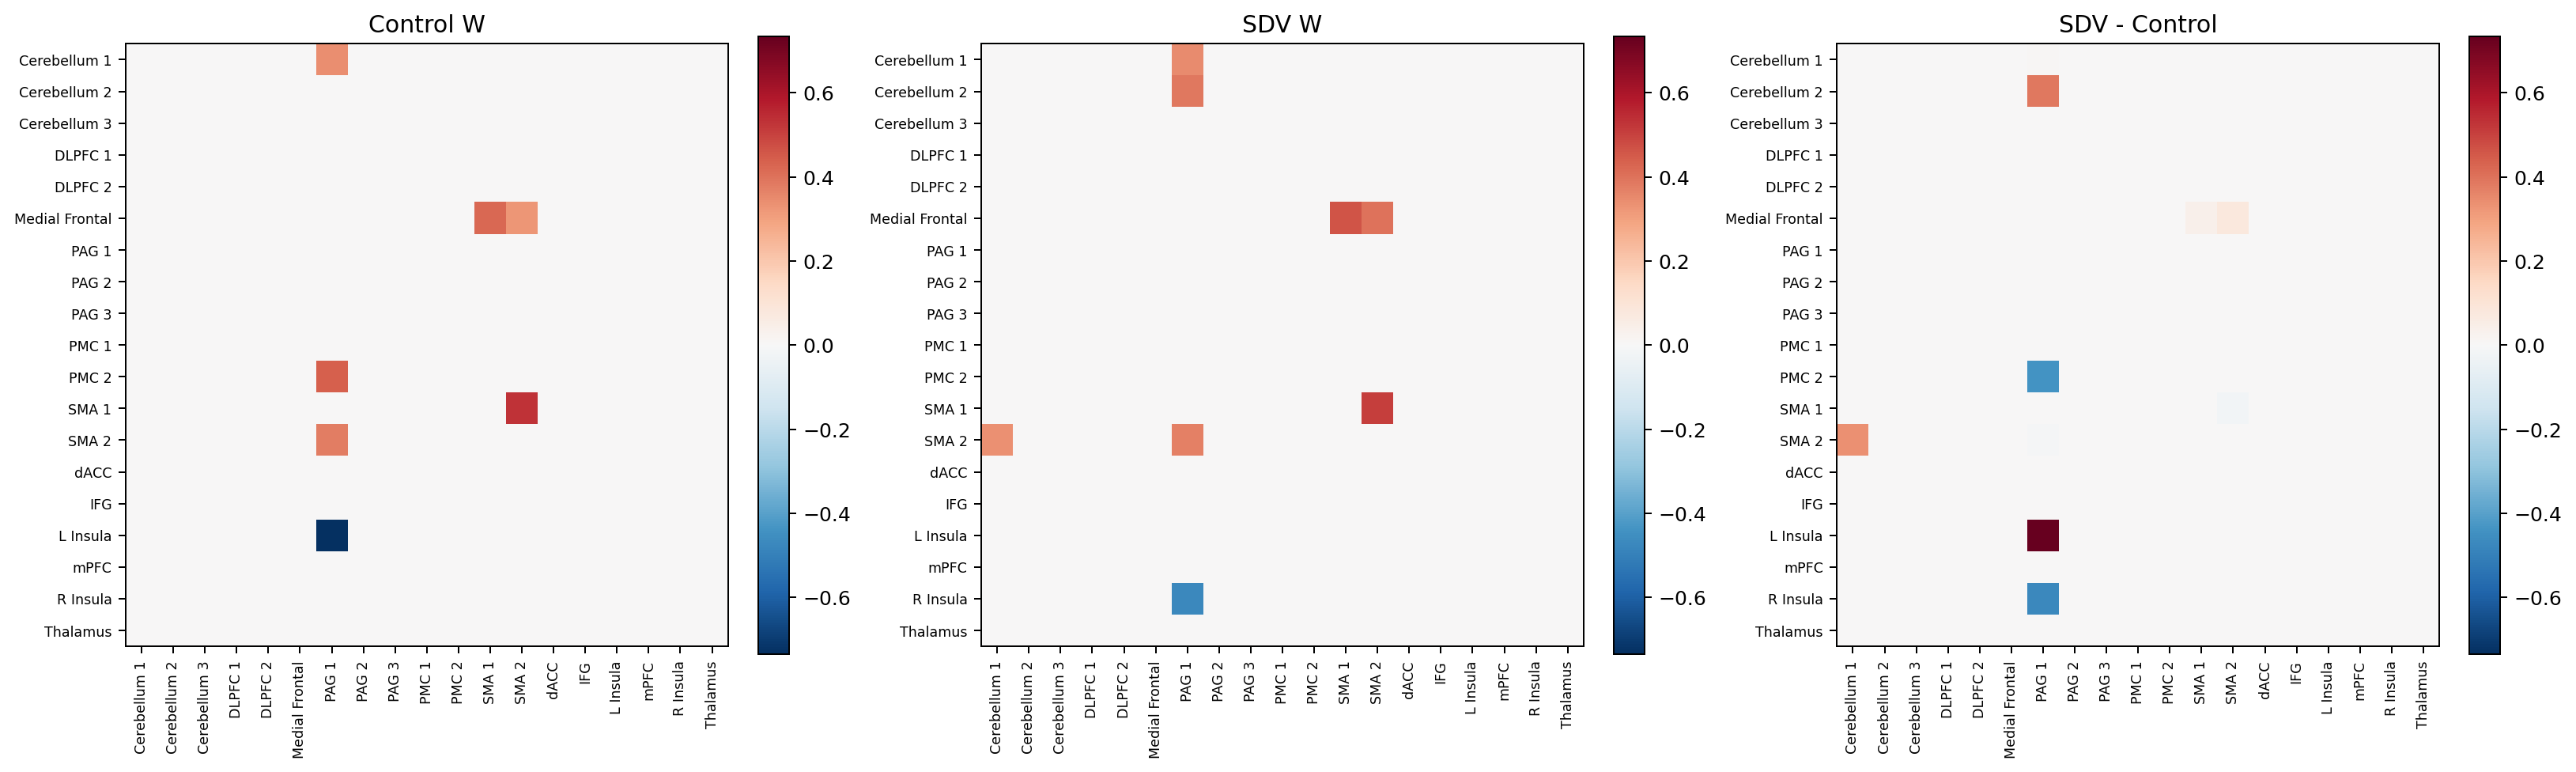

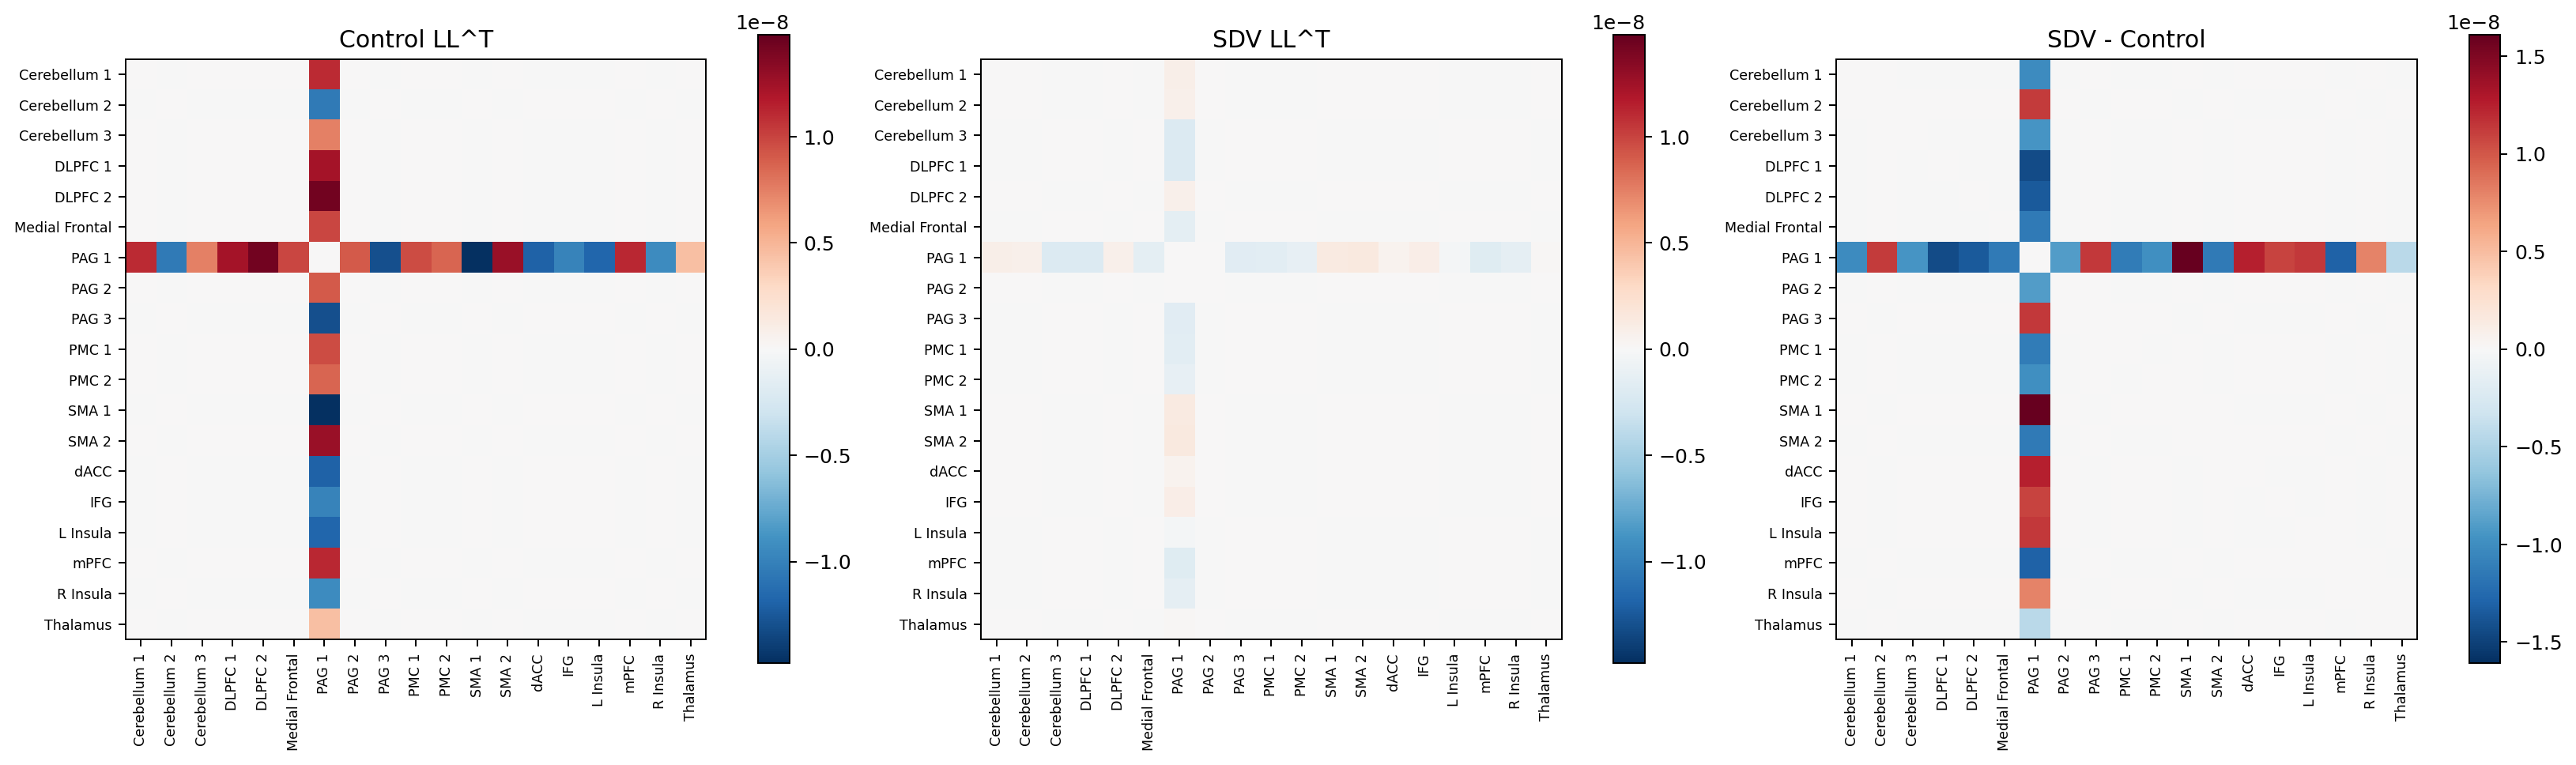

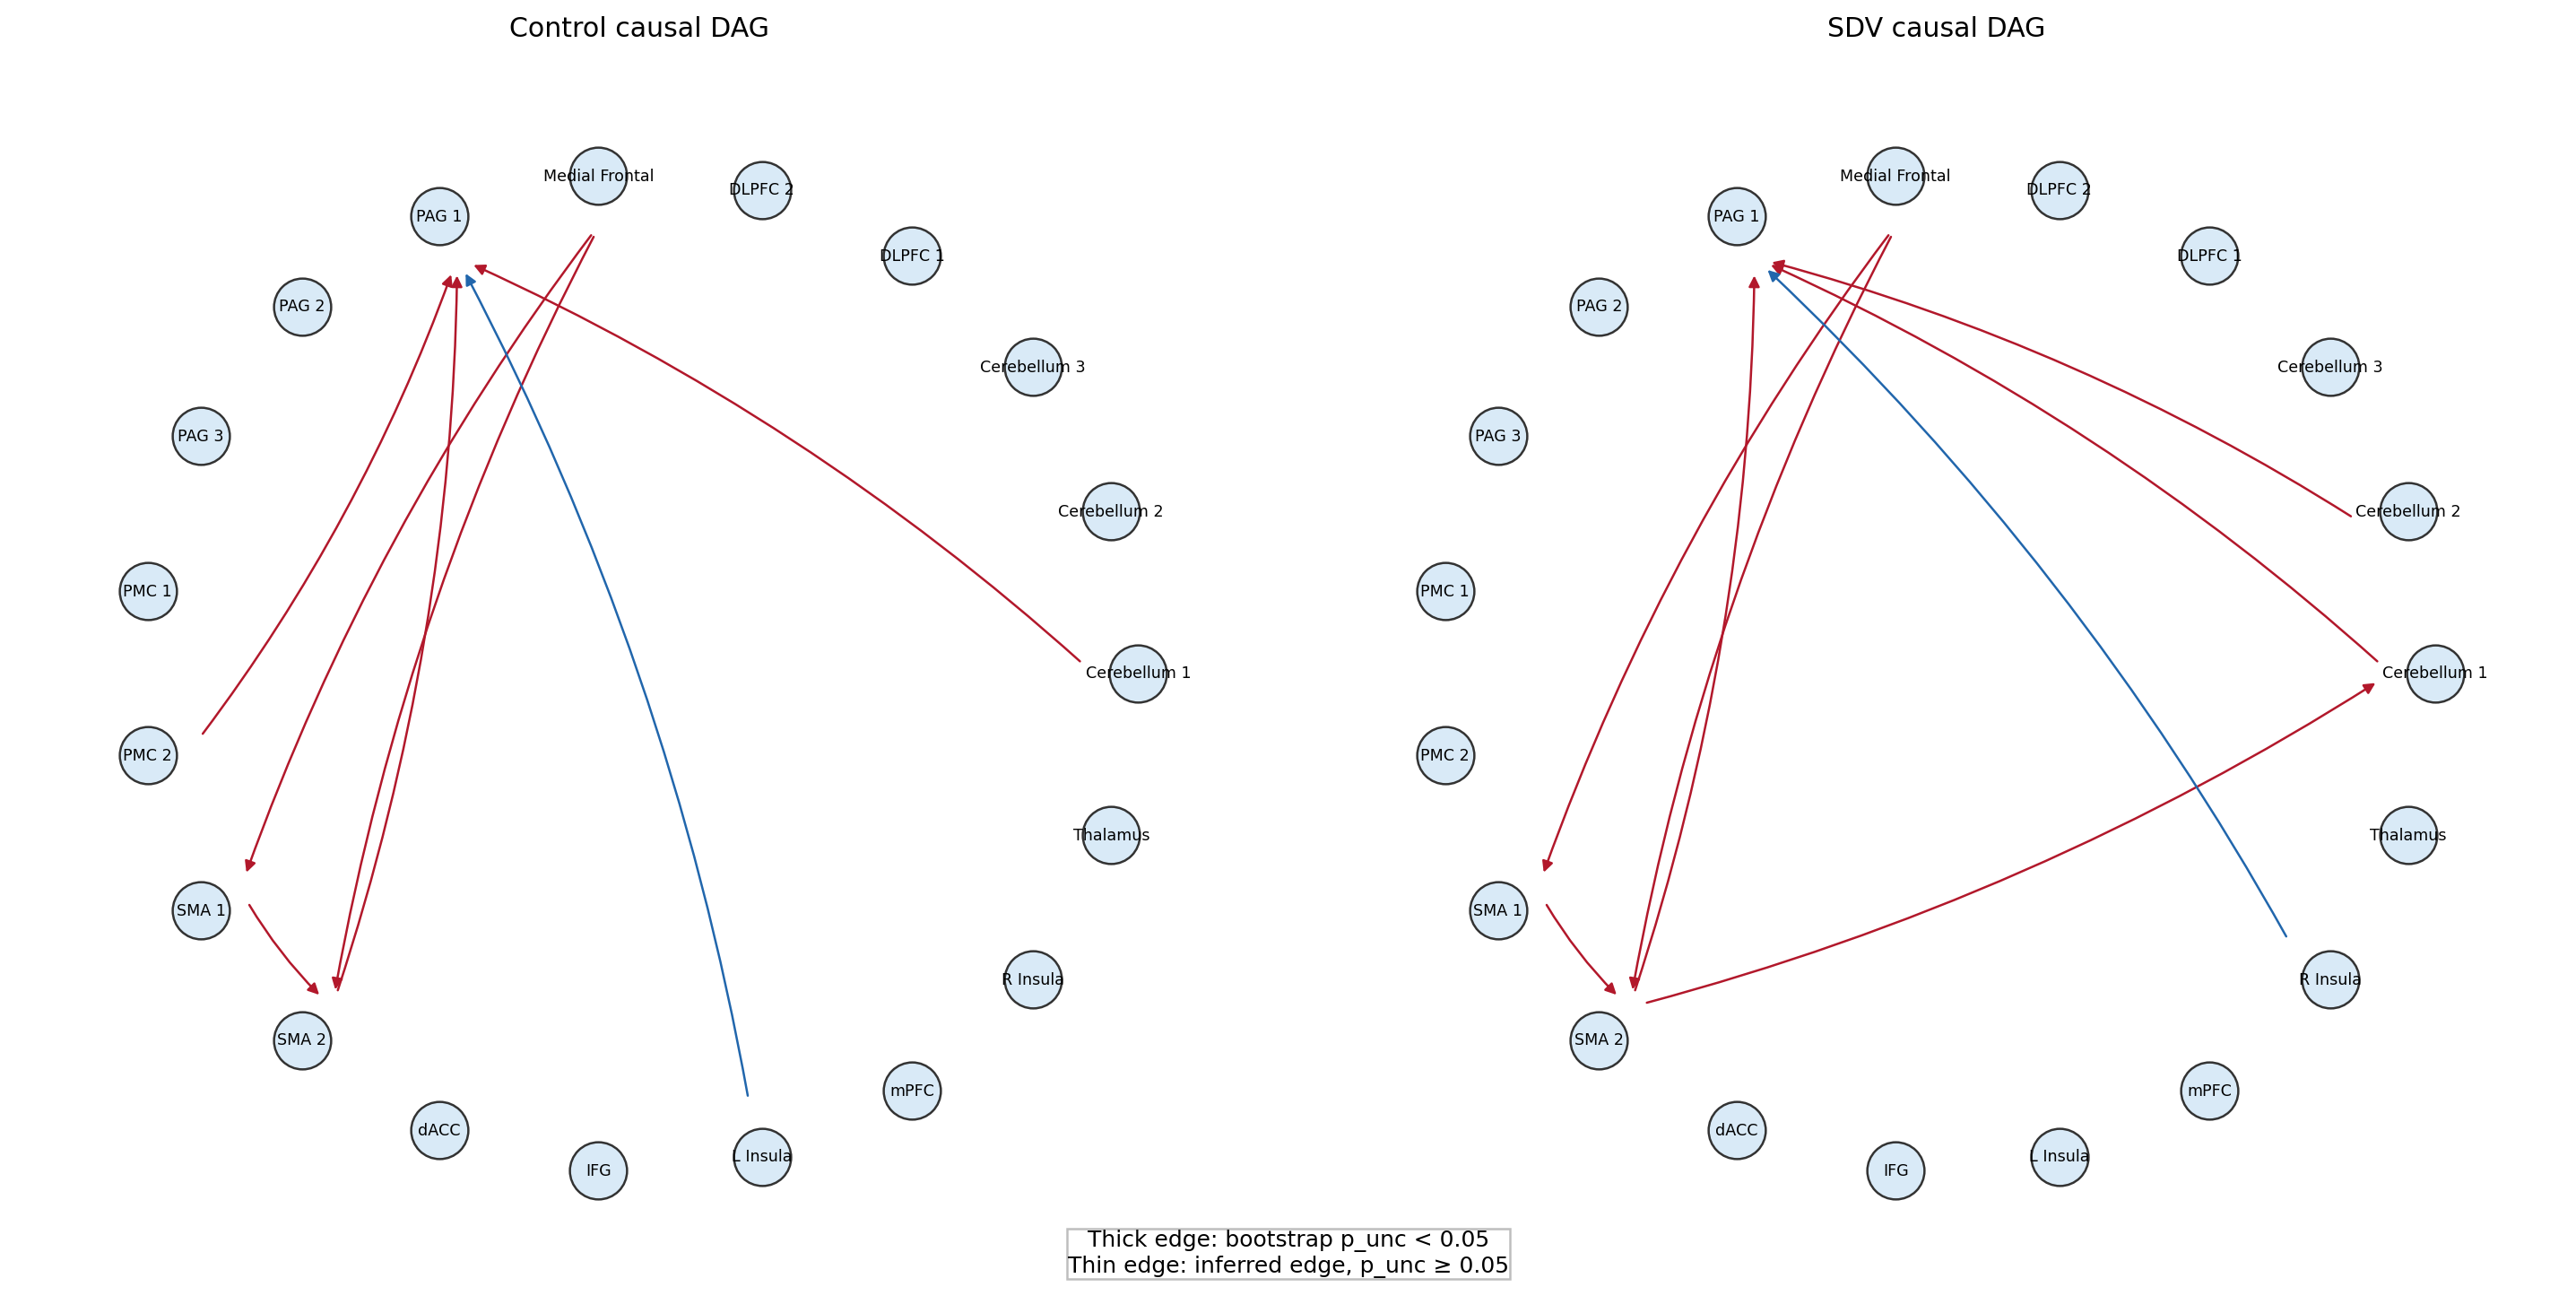

{'directed_edges': 7, 'directed_abs_sum': 3.1665328360140537, 'directed_abs_mean': 0.4523618337162934, 'W_fro': 1.2463279554831819, 'h': 0.0, 'latent_fro': 3.144244095620088e-06, 'latent_offdiag_abs_mean': 1.1542773894309552e-09}
{'directed_edges': 8, 'directed_abs_sum': 3.279884505144291, 'directed_abs_mean': 0.40998556314303636, 'W_fro': 1.1717091373940278, 'h': 0.0, 'latent_fro': 3.614382366765747e-07, 'latent_offdiag_abs_mean': 1.2194625790352412e-10}


In [7]:
S_control=latent_similarity(static_control); S_sdv=latent_similarity(static_sdv)
plot_matrix_comparison(static_control.W0,static_sdv.W0,BLADDER19_LABELS,('Control W','SDV W','SDV - Control'),OUTPUT/'static_W_comparison.png')
plot_matrix_comparison(S_control,S_sdv,BLADDER19_LABELS,('Control LL^T','SDV LL^T','SDV - Control'),OUTPUT/'static_latent_comparison.png',True)
plot_graph_comparison(static_control.W0,static_sdv.W0,BLADDER19_LABELS,OUTPUT/'static_graph_comparison.png',EDGE_THRESHOLD)
for filename in ('static_W_comparison.png','static_latent_comparison.png','static_graph_comparison.png'):
    display(Image(filename=str(OUTPUT/filename)))
print(model_statistics(static_control.W0,S_control,static_control.diagnostics['h_thresholded']))
print(model_statistics(static_sdv.W0,S_sdv,static_sdv.diagnostics['h_thresholded']))

In [16]:
import importlib
import causal_opt.fmri
importlib.reload(causal_opt.fmri)
from causal_opt.fmri import *

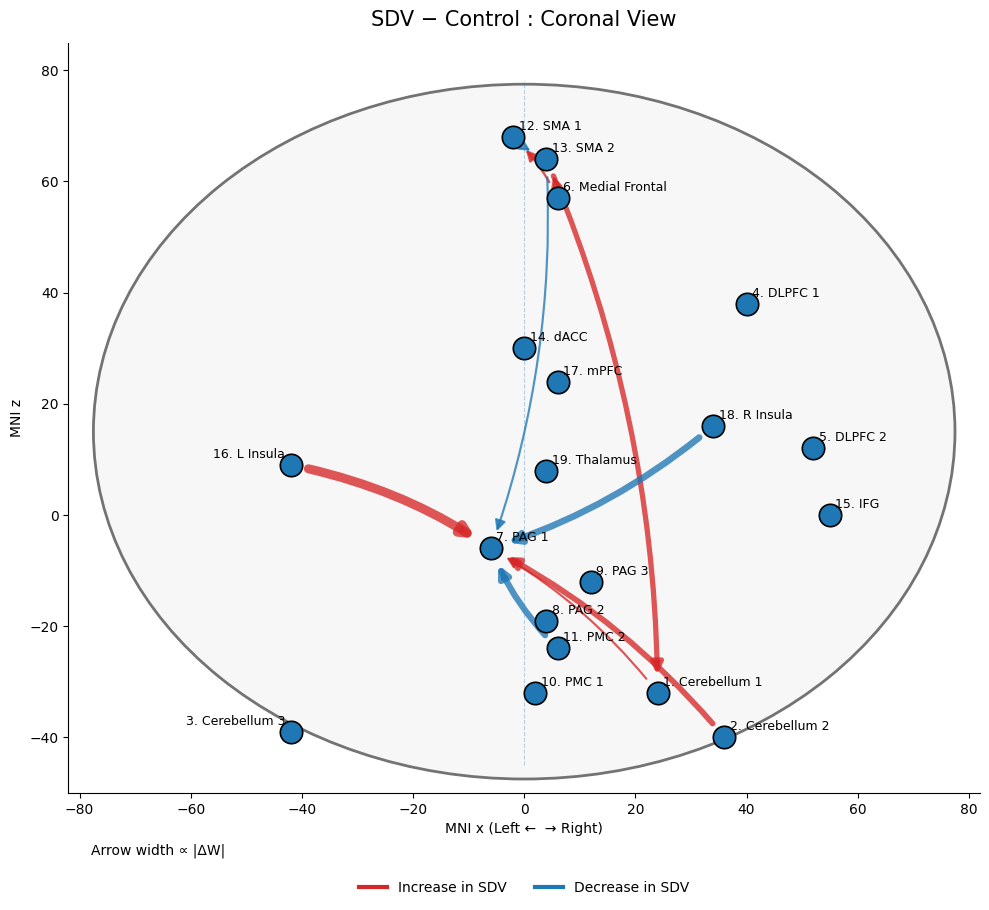

In [8]:
from causal_opt.fmri import BLADDER19_LABELS, plot_anatomical_graph_difference
import matplotlib.pyplot as plt

case2_difference_path = (
    OUTPUT / "case2_sdv_minus_control_coronal.png"
)

fig, ax = plot_anatomical_graph_difference(
    static_control.W0,
    static_sdv.W0,
    control.roi_xyz,
    BLADDER19_LABELS,
    output_path=case2_difference_path,
    view="coronal", # sagittal
    title="SDV − Control : Coronal View", # Sagittal View
)

plt.show()

## Case 2 — Baseline comparison
These cells load the official NOTEARS and endpoint-coded FCI results produced by the analysis script. FCI is summarized as a PAG; weighted-DAG metrics are intentionally shown as N/A.

In [11]:
import pandas as pd
INFERENCE_OUTPUT=Path(os.getenv('FMRI_INFERENCE_OUTPUT',ROOT/'results'/'fmri_control_sdv'))
baseline_csv=INFERENCE_OUTPUT/'case2_baseline_summary.csv'
if baseline_csv.exists():
    baseline_summary=pd.read_csv(baseline_csv)
    display(baseline_summary)
    for filename in ('static_control_proposed_vs_notears.png','static_sdv_proposed_vs_notears.png','notears_W_comparison.png','static_control_proposed_vs_notears_graph.png','static_sdv_proposed_vs_notears_graph.png','fci_pag_comparison.png','fci_skeleton_comparison.png'):
        path=INFERENCE_OUTPUT/filename
        if path.exists(): display(Image(filename=str(path)))
else:
    print('Cached baseline results not found. Run scripts/run_fmri_causal_analysis.py --case2-baselines --reuse-static-results first.')

Cached baseline results not found. Run scripts/run_fmri_causal_analysis.py --case2-baselines --reuse-static-results first.


## Case 2 — Patient-wise bootstrap inference
The statistical unit is the paired subject. These cells only load resumable cached bootstrap fits; opening the notebook never launches 1,000 optimizations. Inference uses raw, pre-threshold W matrices.

{'off_diagonal_tests': 342, 'nominal_p_lt_0.05': 6, 'fdr_q_lt_0.05': 0}
Nominal uncorrected edges:


,source_index,source_name,target_index,target_name,W_control_observed,W_sdv_observed,delta_W_observed,bootstrap_mean_delta,bootstrap_median_delta,ci_2.5,ci_97.5,p_boot,q_fdr,ci_excludes_zero,fdr_significant,control_selection_probability,sdv_selection_probability,control_positive_probability,sdv_positive_probability,abs_delta_W
0,3,Dorsolateral Prefrontal Cortex 1,6,PAG1,0.137239,-0.202989,-0.340228,-0.355831,-0.360895,-0.584450,-0.119064,0.001998,0.683317,True,False,0.059,0.099,0.939,0.001,0.340228
3,10,PMC 2,6,PAG1,0.436549,-0.010225,-0.446775,-0.413116,-0.403381,-0.785498,-0.083135,0.005994,1.000000,True,False,0.684,0.002,0.995,0.280,0.446775
2,1,Cerebellum 2,6,PAG1,-0.273711,0.384857,0.658567,0.633534,0.643163,0.066315,1.161926,0.013986,1.000000,True,False,0.469,0.620,0.036,0.978,0.658567
6,12,Supplementary Motor Area 2,8,PAG 3,0.248160,0.000000,-0.248160,-0.214577,-0.211625,-0.423092,-0.008748,0.025974,1.000000,True,False,0.246,0.001,0.985,0.311,0.248160
17,16,Medial Prefrontal Cortex,2,Cerebellum 3,0.121133,-0.042214,-0.163348,-0.141108,-0.138076,-0.295269,0.000000,0.034965,1.000000,False,False,0.007,0.000,0.796,0.000,0.163348
10,9,PMC 1,6,PAG1,0.216758,-0.000057,-0.216815,-0.201382,-0.202327,-0.407949,-0.000998,0.040959,1.000000,True,False,0.137,0.000,0.974,0.207,0.216815


BH-FDR supported edges:


,result
0,No edge survives BH-FDR at q < 0.05.


,roi,incoming_change,outgoing_change,total_change
0,PAG1,3.828329,0.004350,3.832679
1,Cerebellum 2,0.920621,0.867911,1.788532
2,Cerebellum 3,1.390644,0.266908,1.657552
3,Thalamus,0.675541,0.949599,1.625140
4,Dorsal Anterior Cingulate Cortex,0.351923,1.161892,1.513815
5,L Insula,0.097798,1.234951,1.332749
6,Inferior Frontal Gyrus,0.576459,0.619167,1.195626
7,Cerebellum 1,0.485516,0.700417,1.185932
8,Supplementary Motor Area 2,0.097486,1.042391,1.139877
9,PMC 2,0.517732,0.583191,1.100923


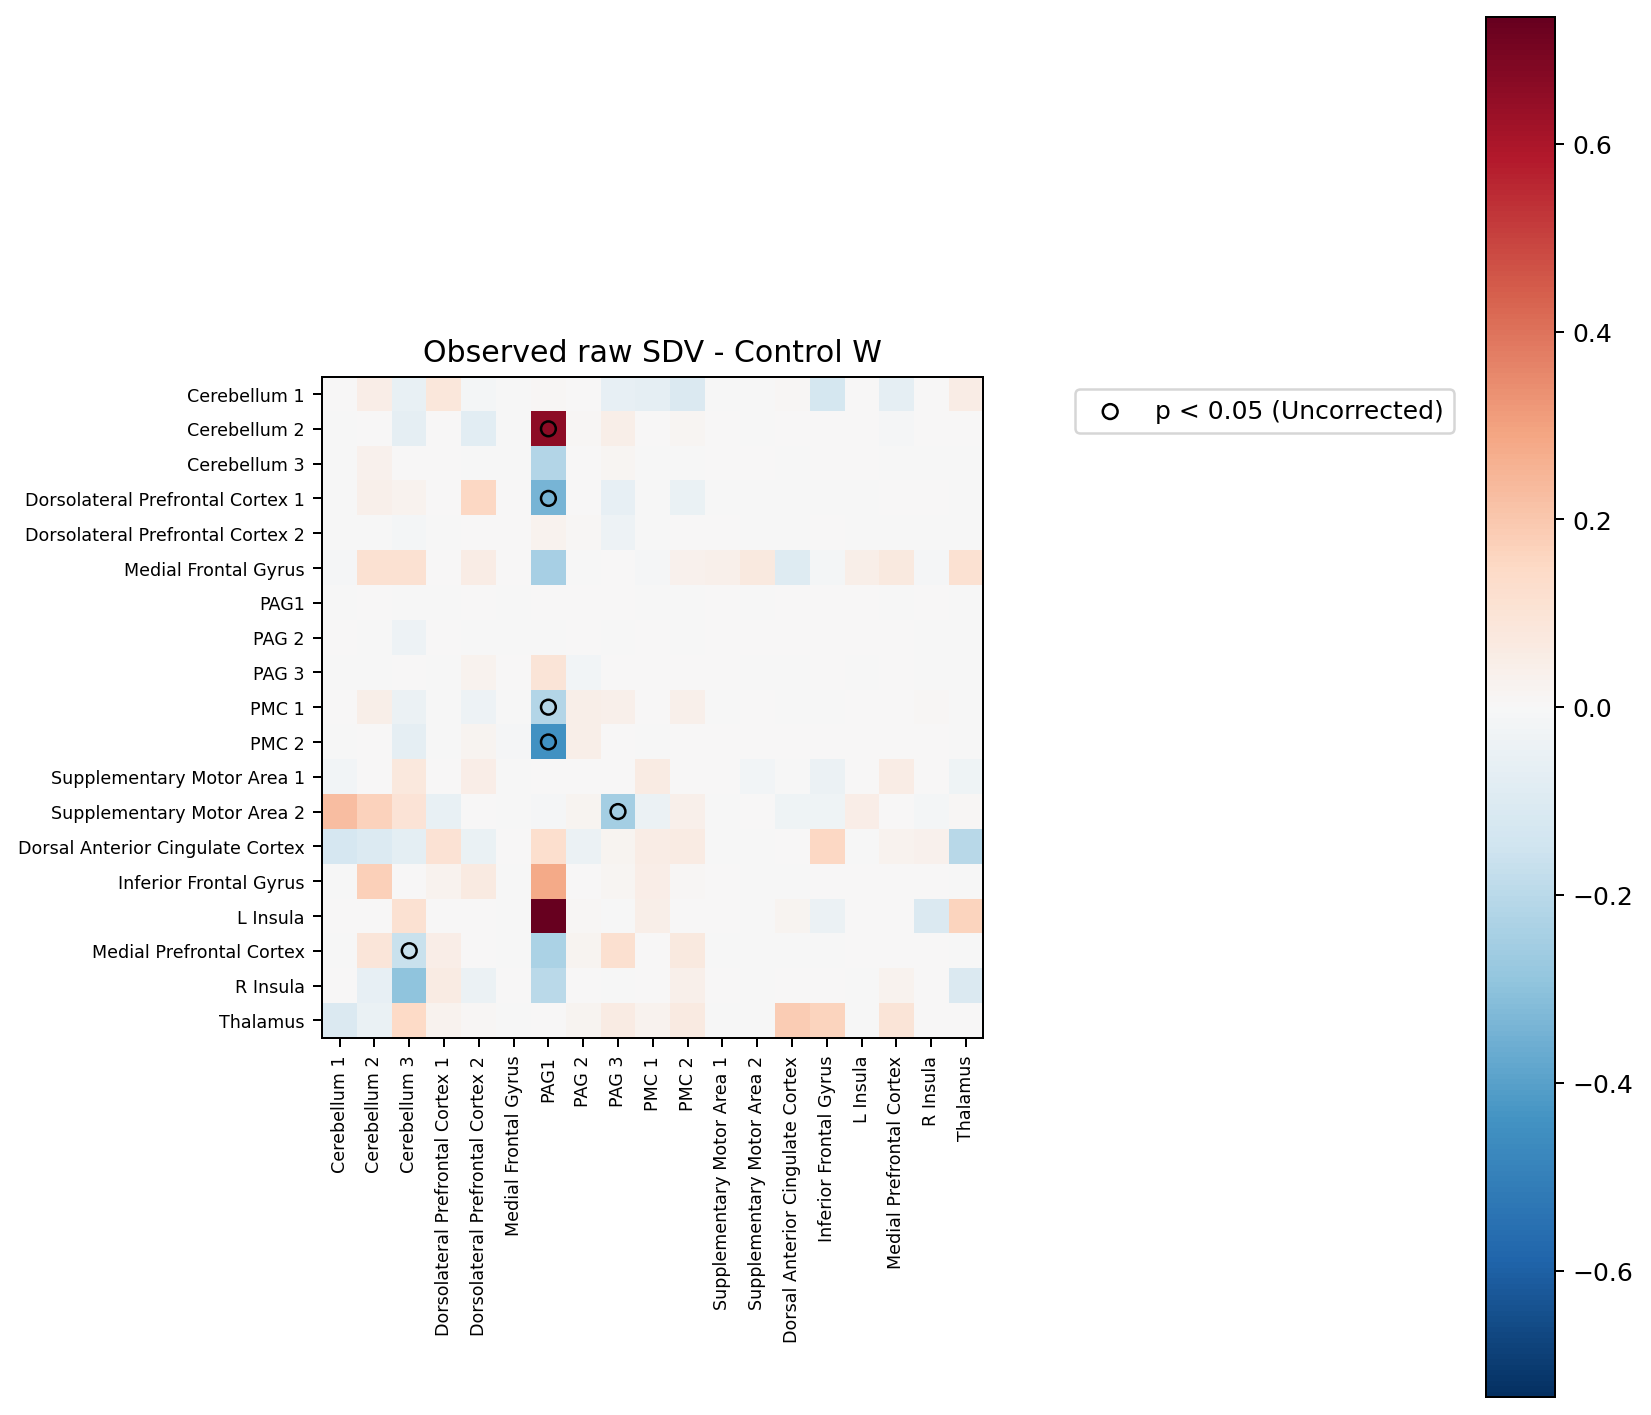

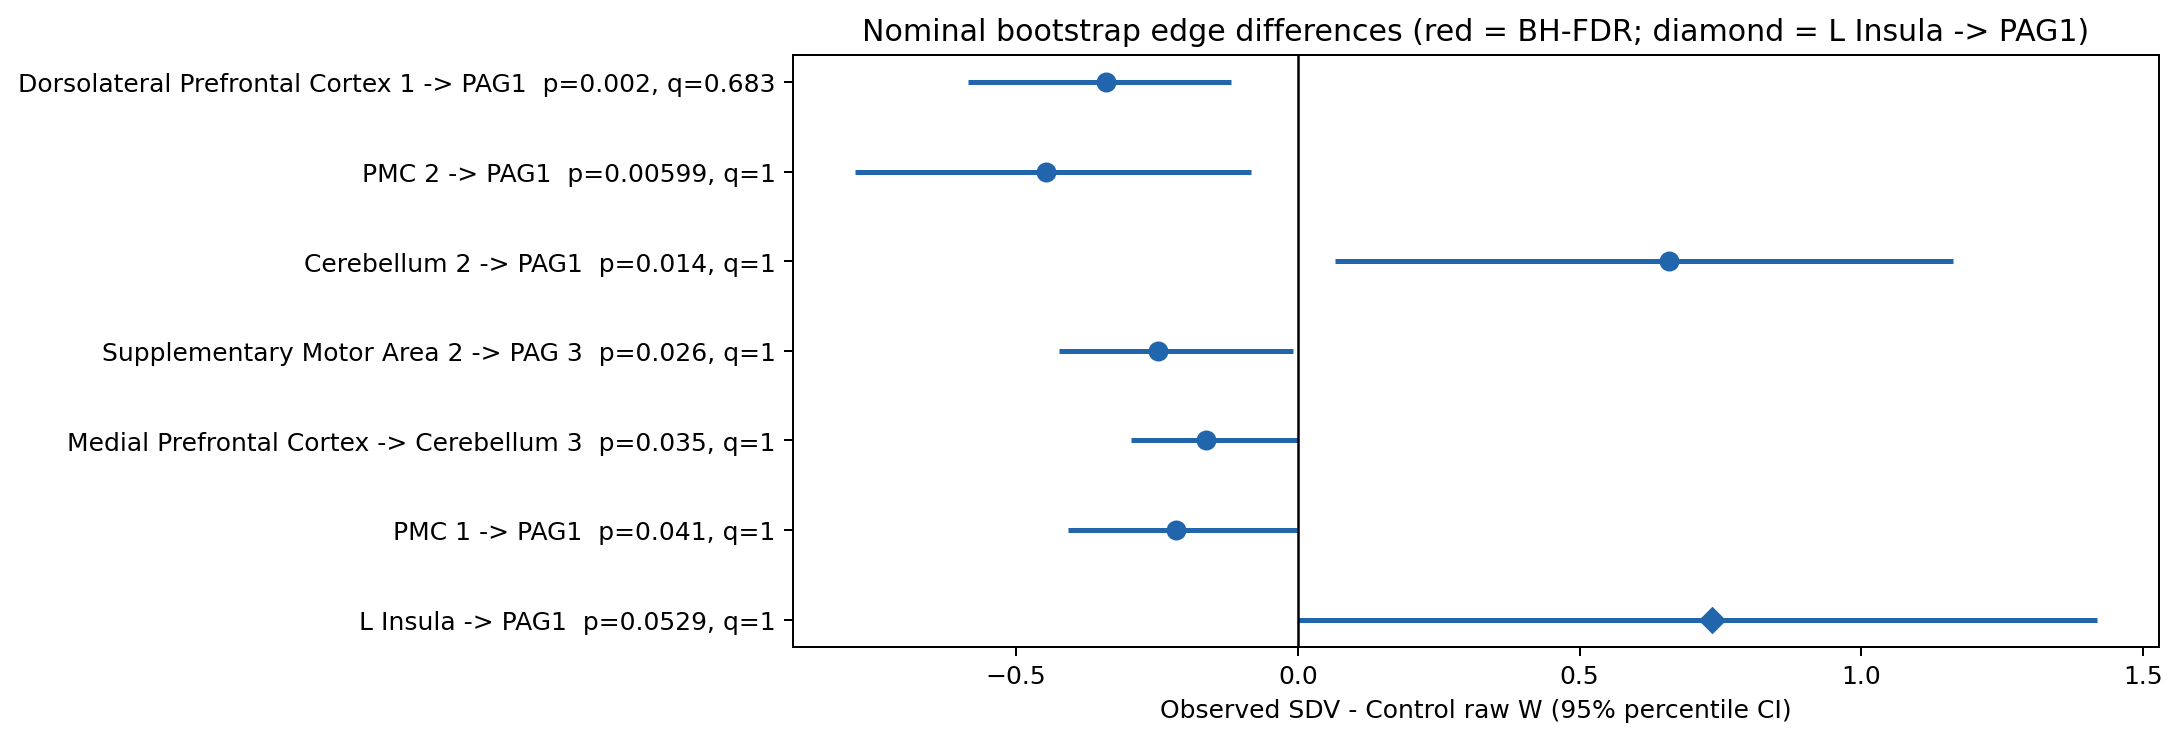

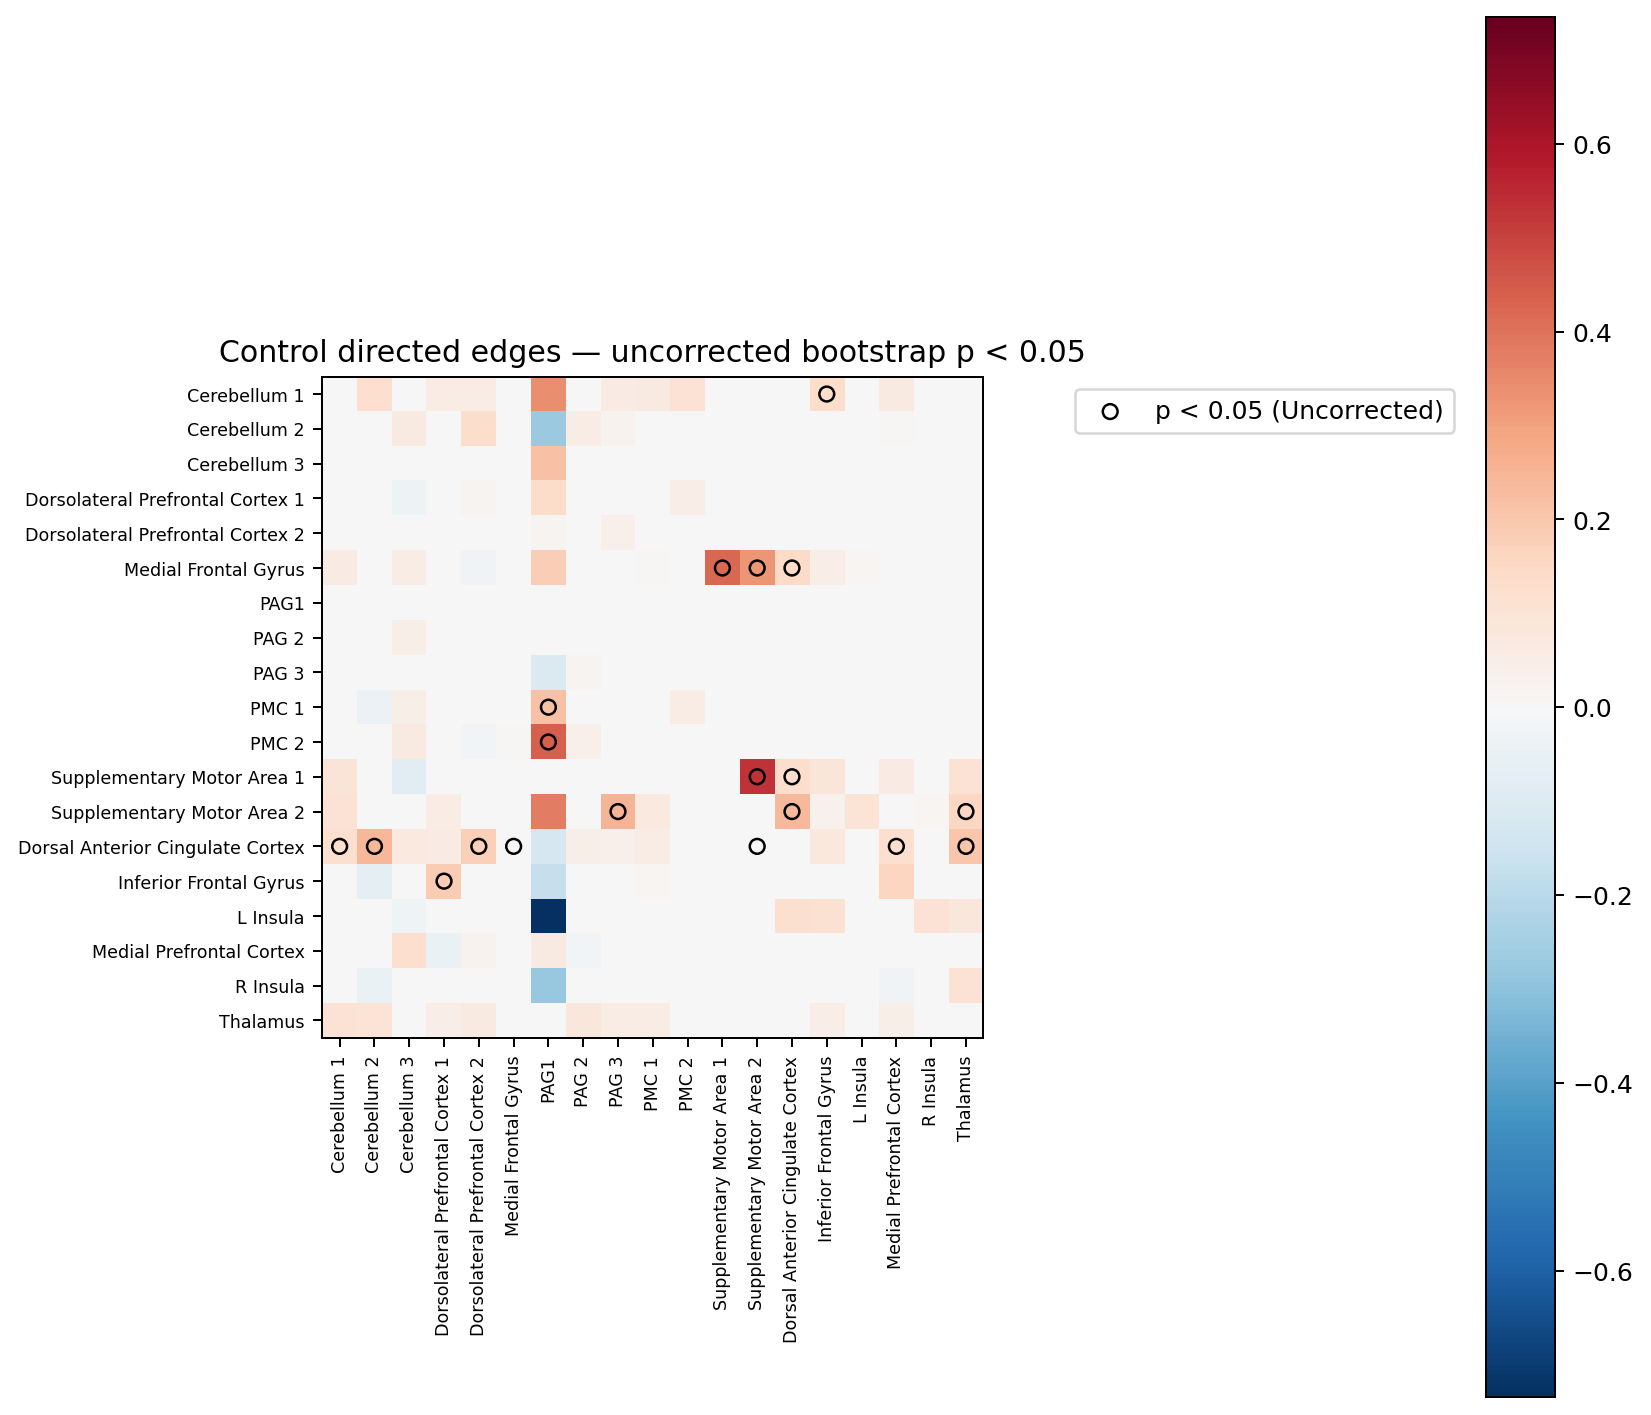

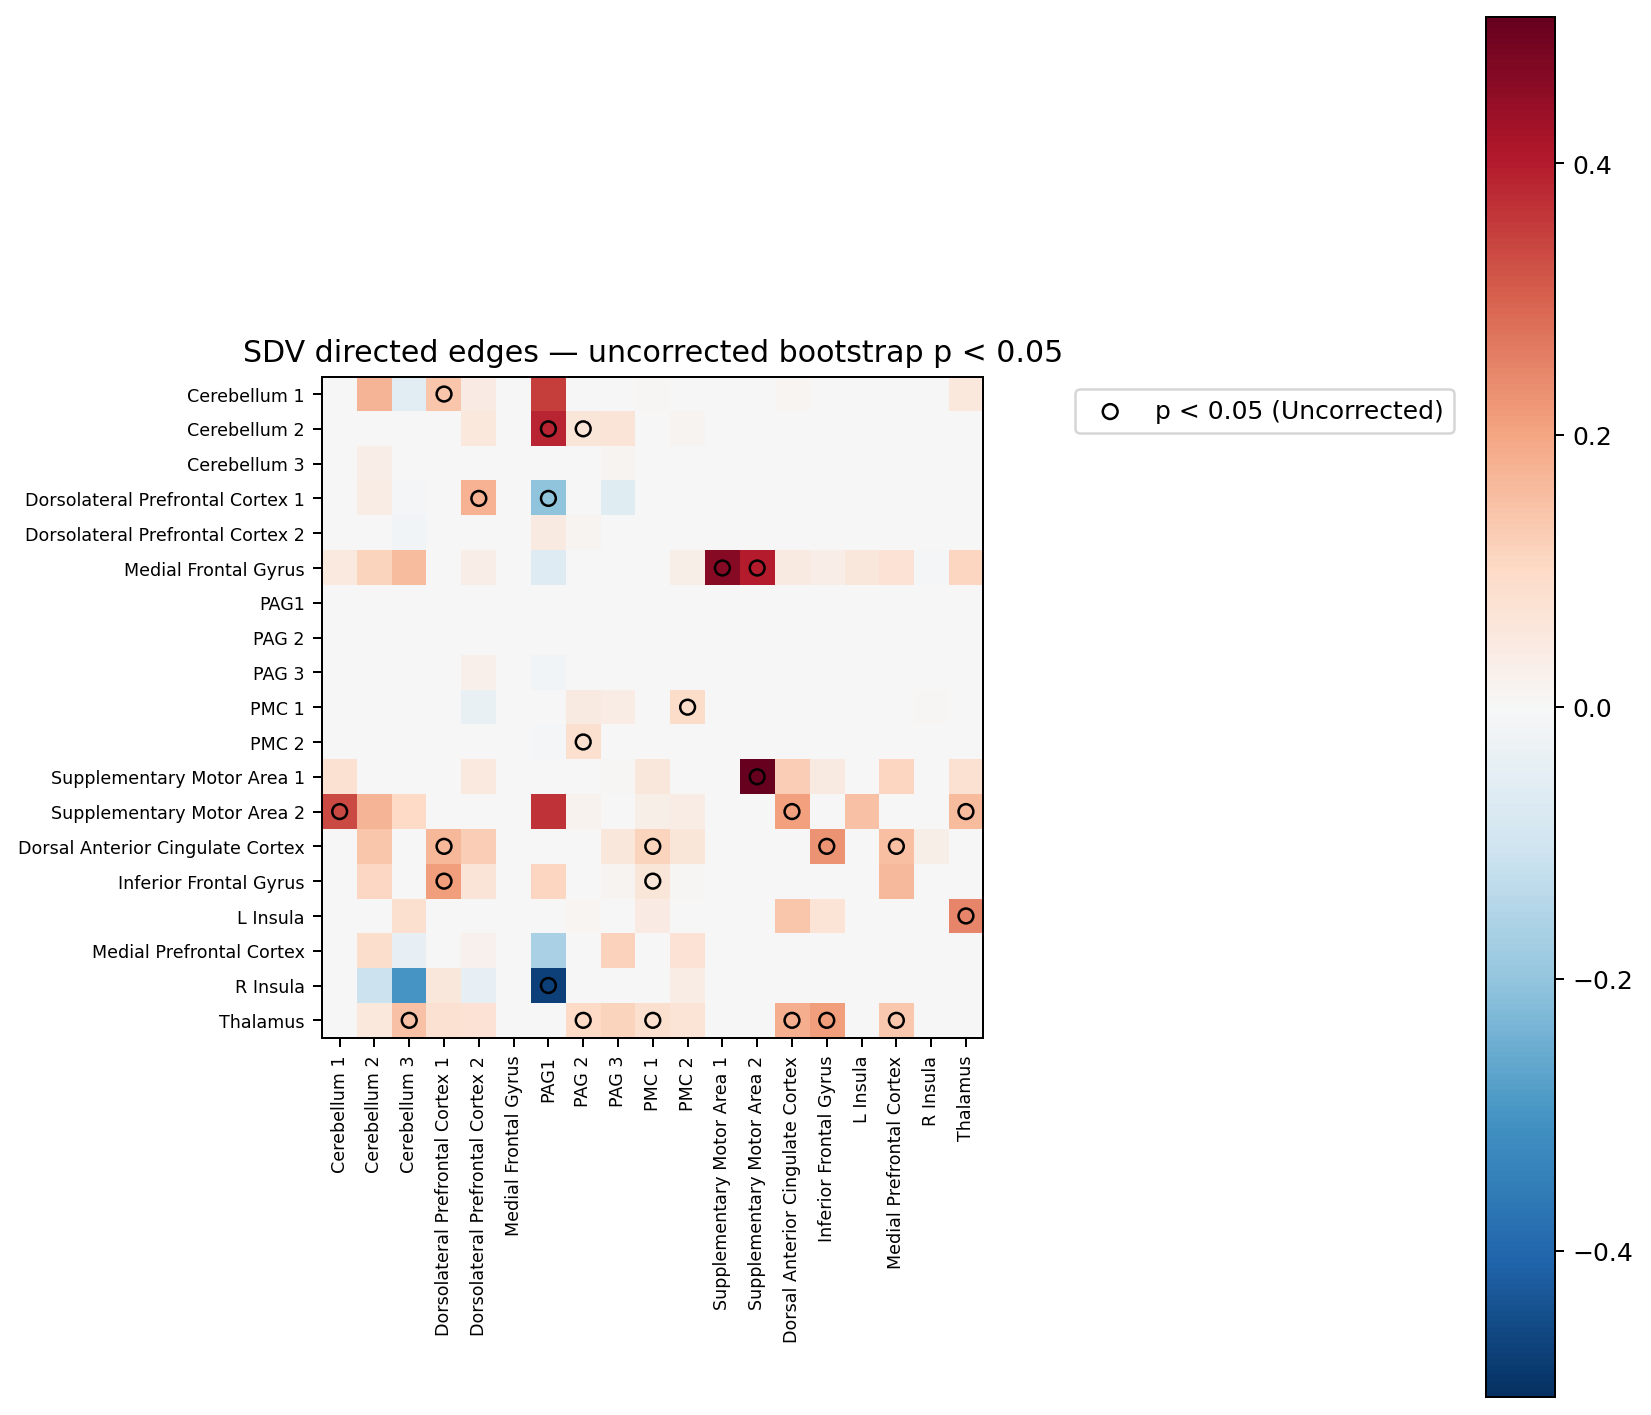

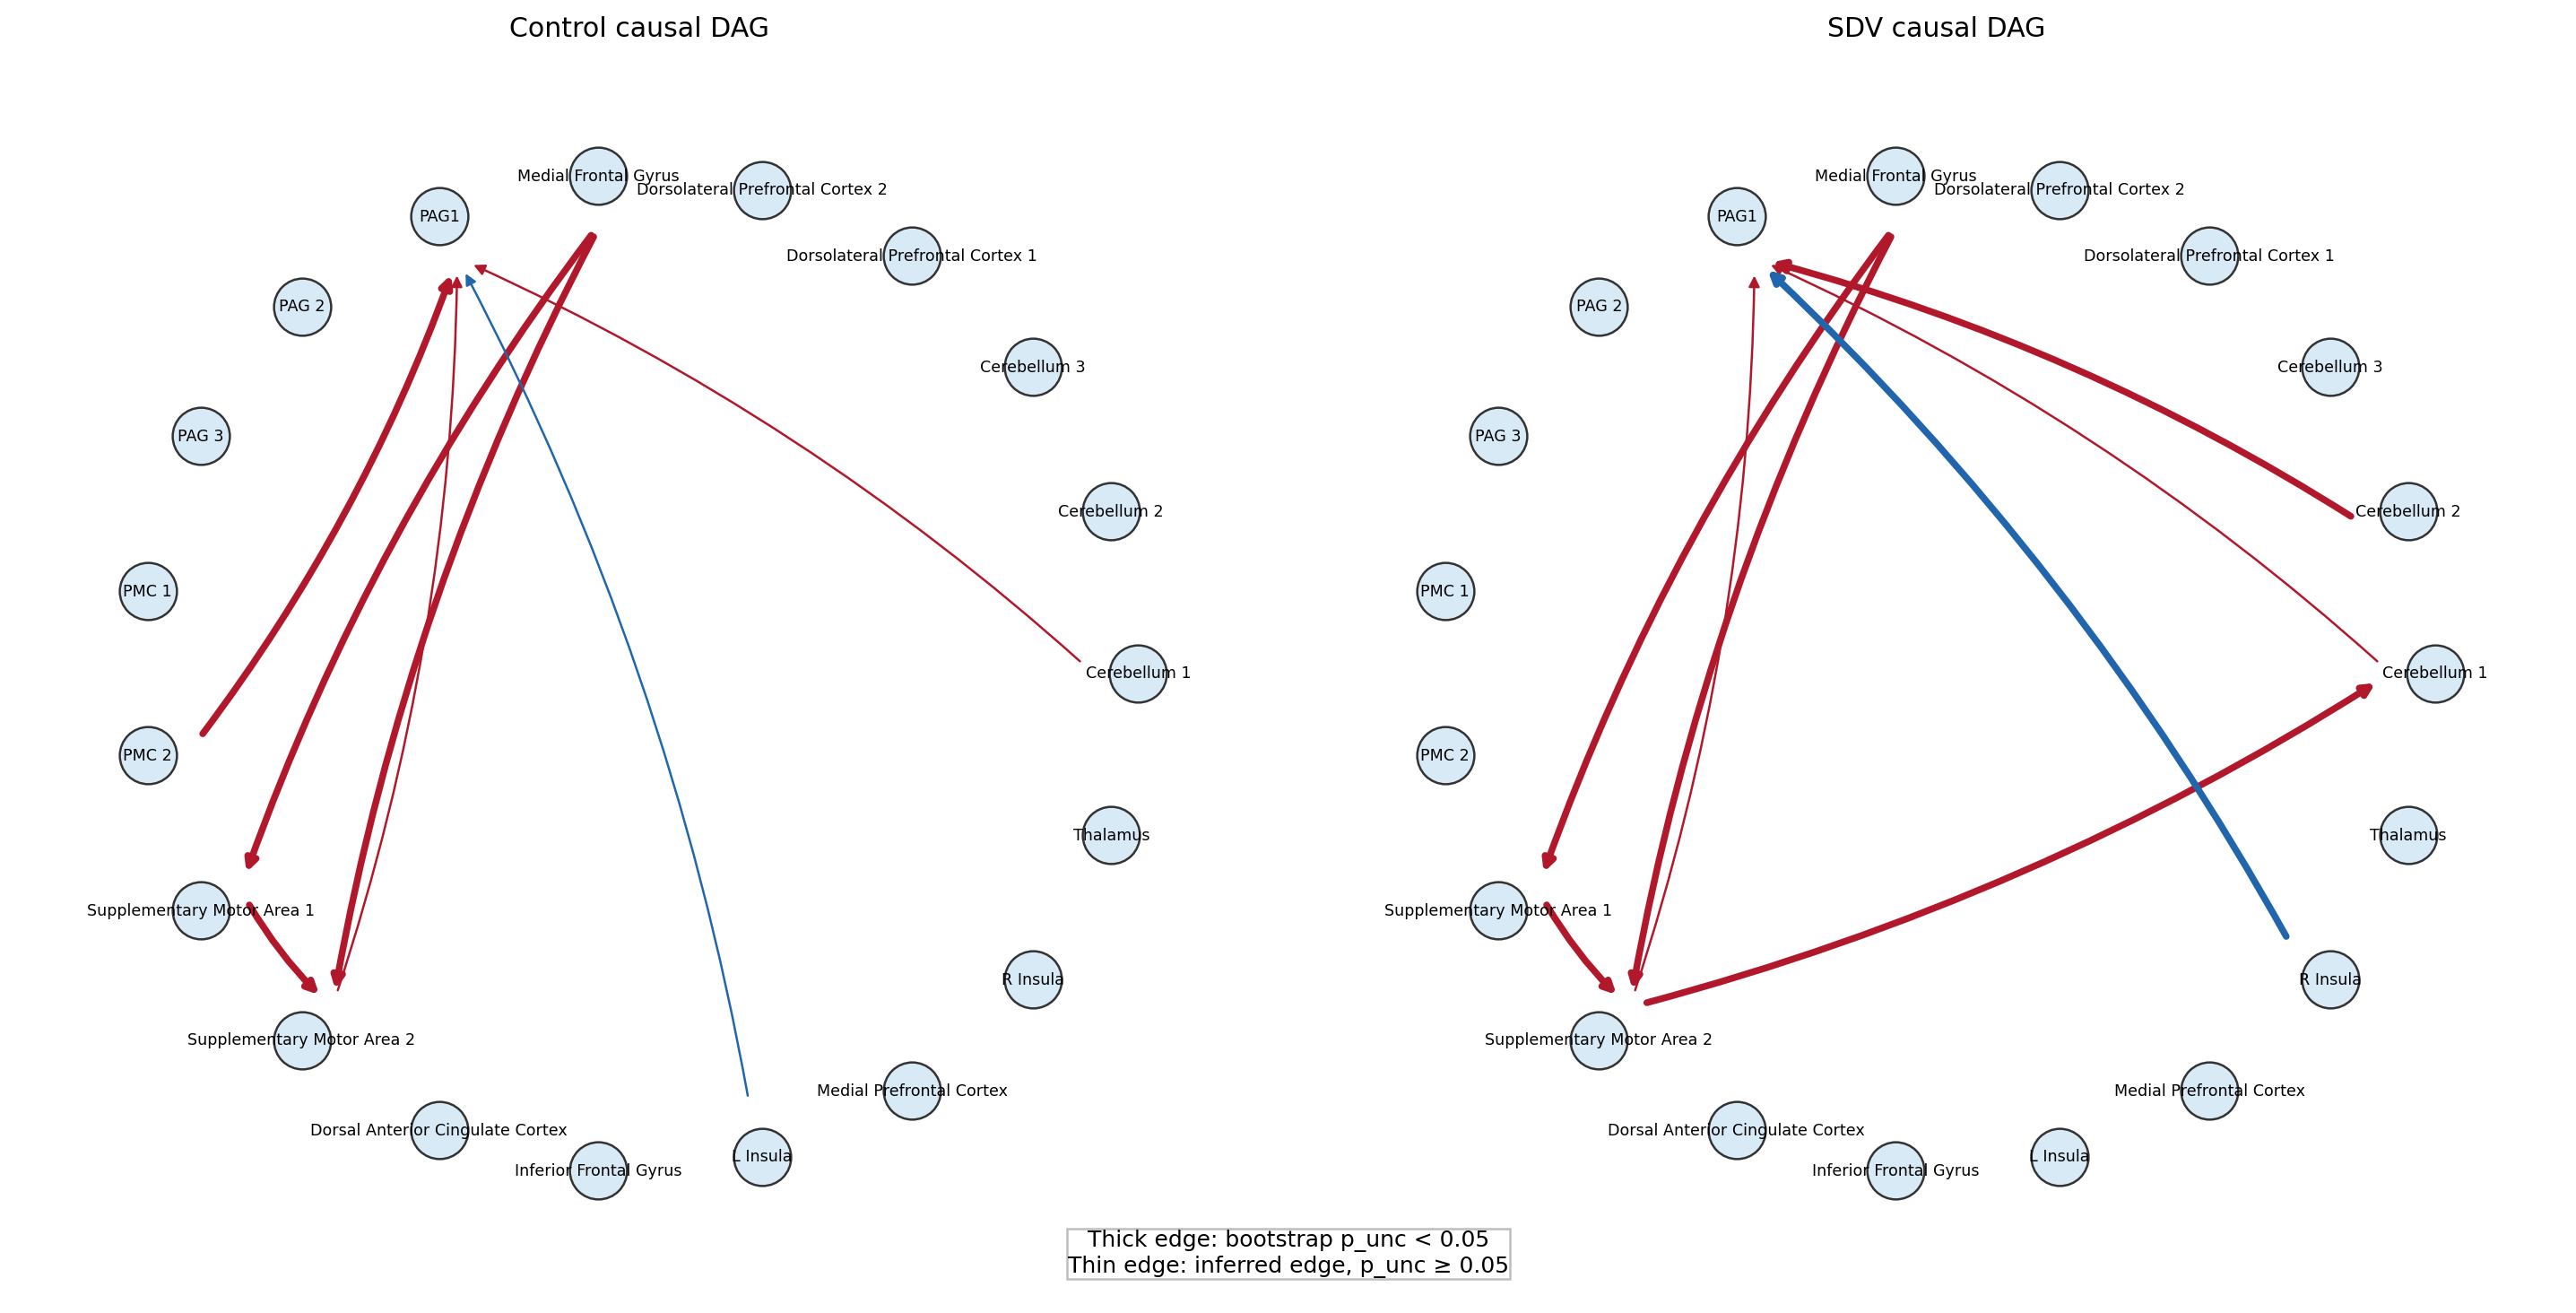

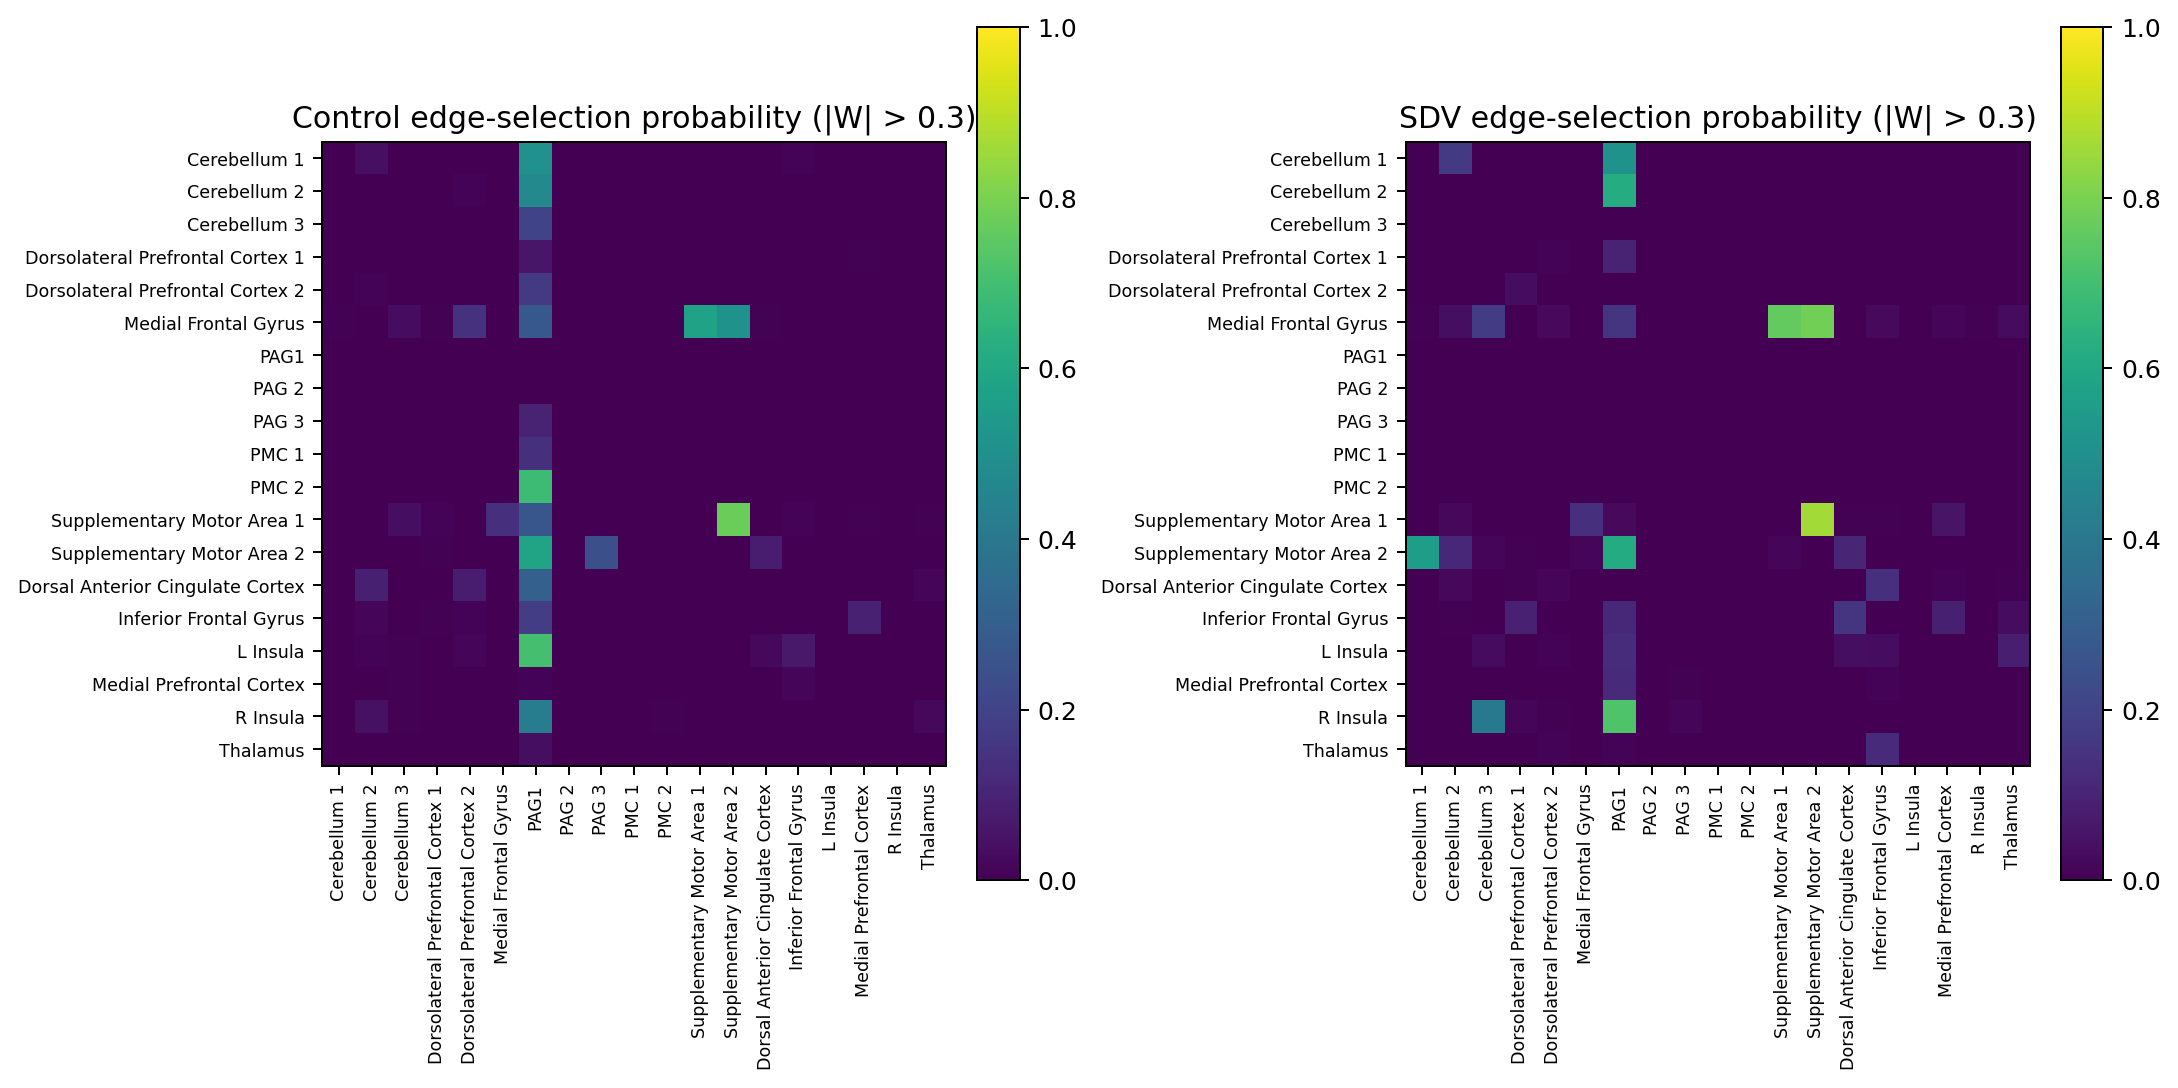

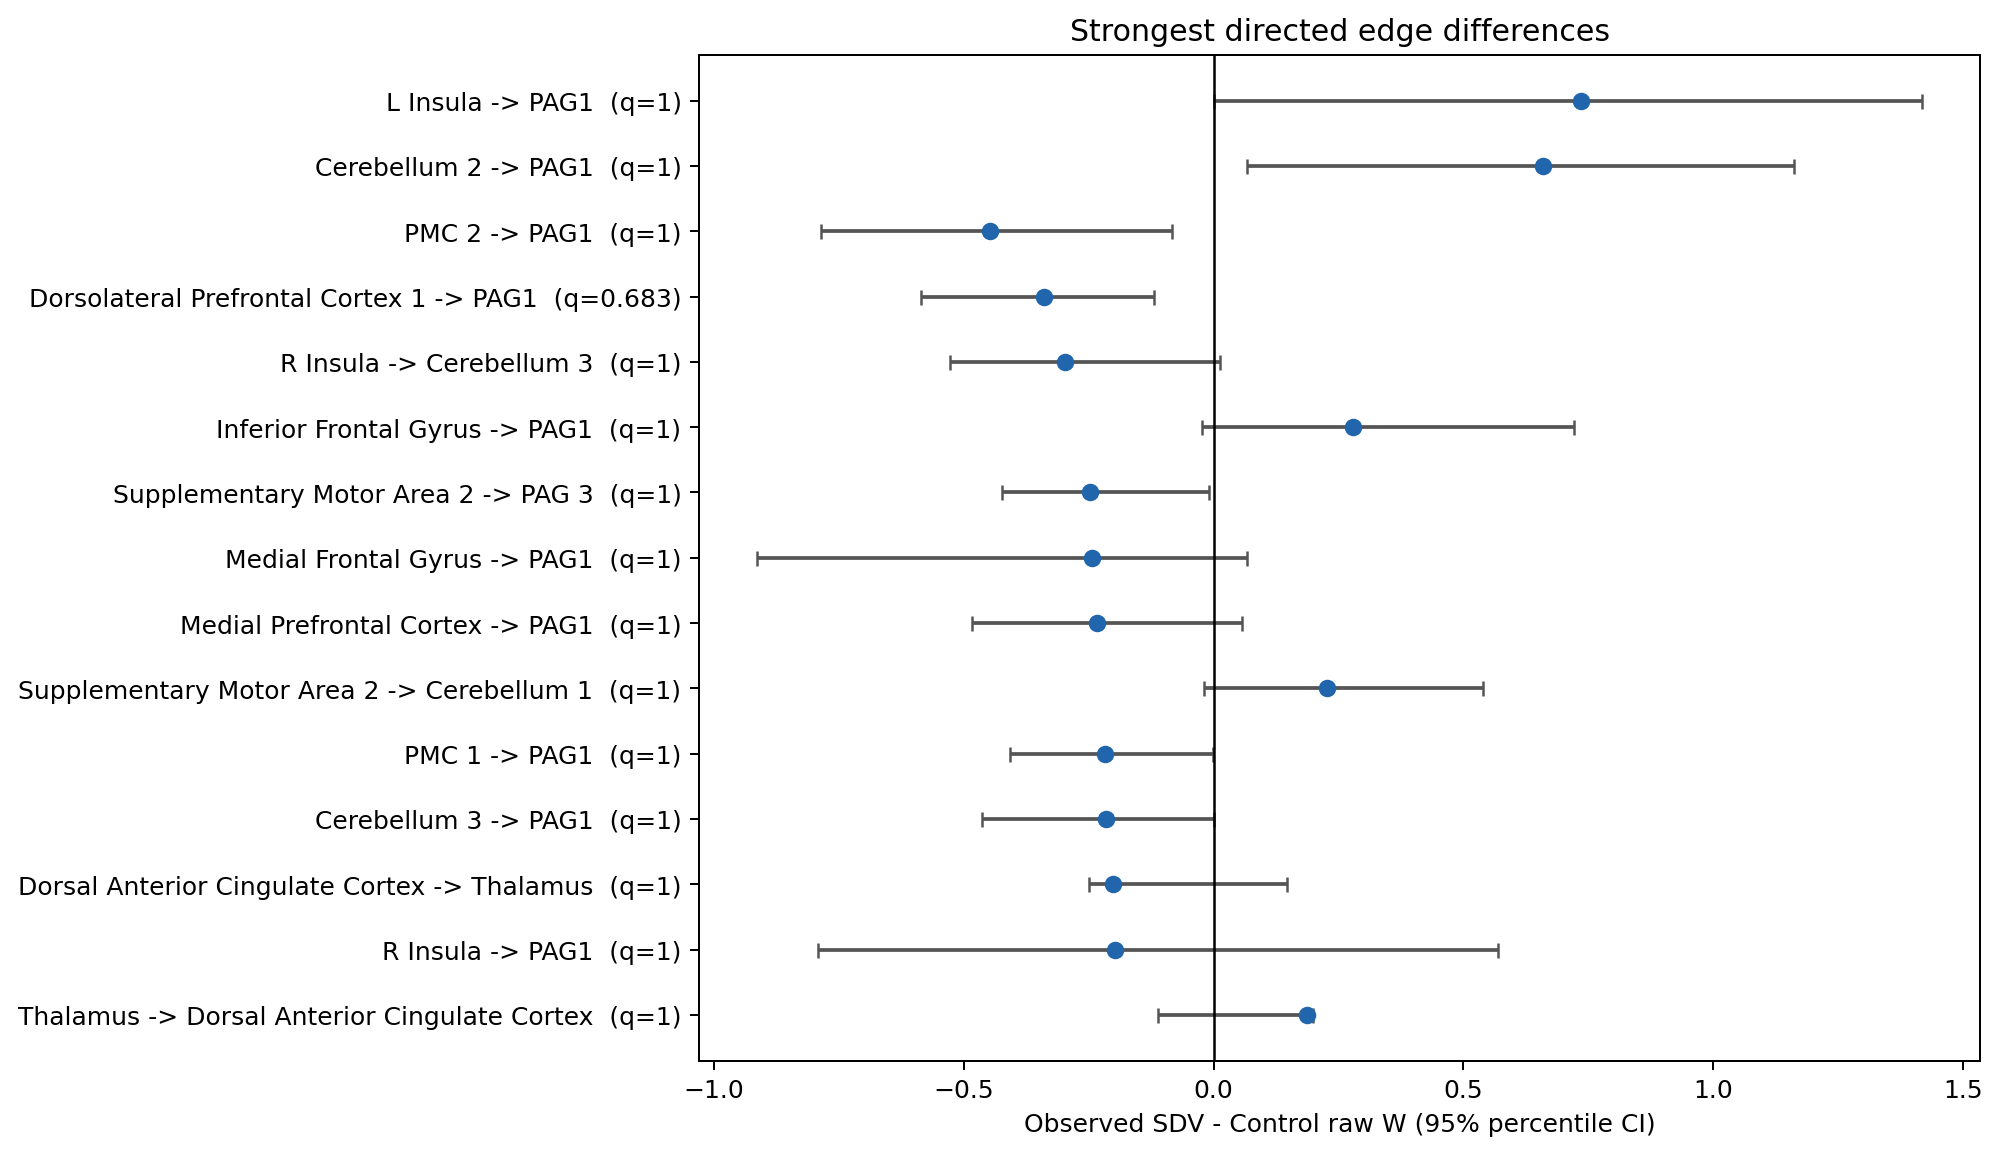

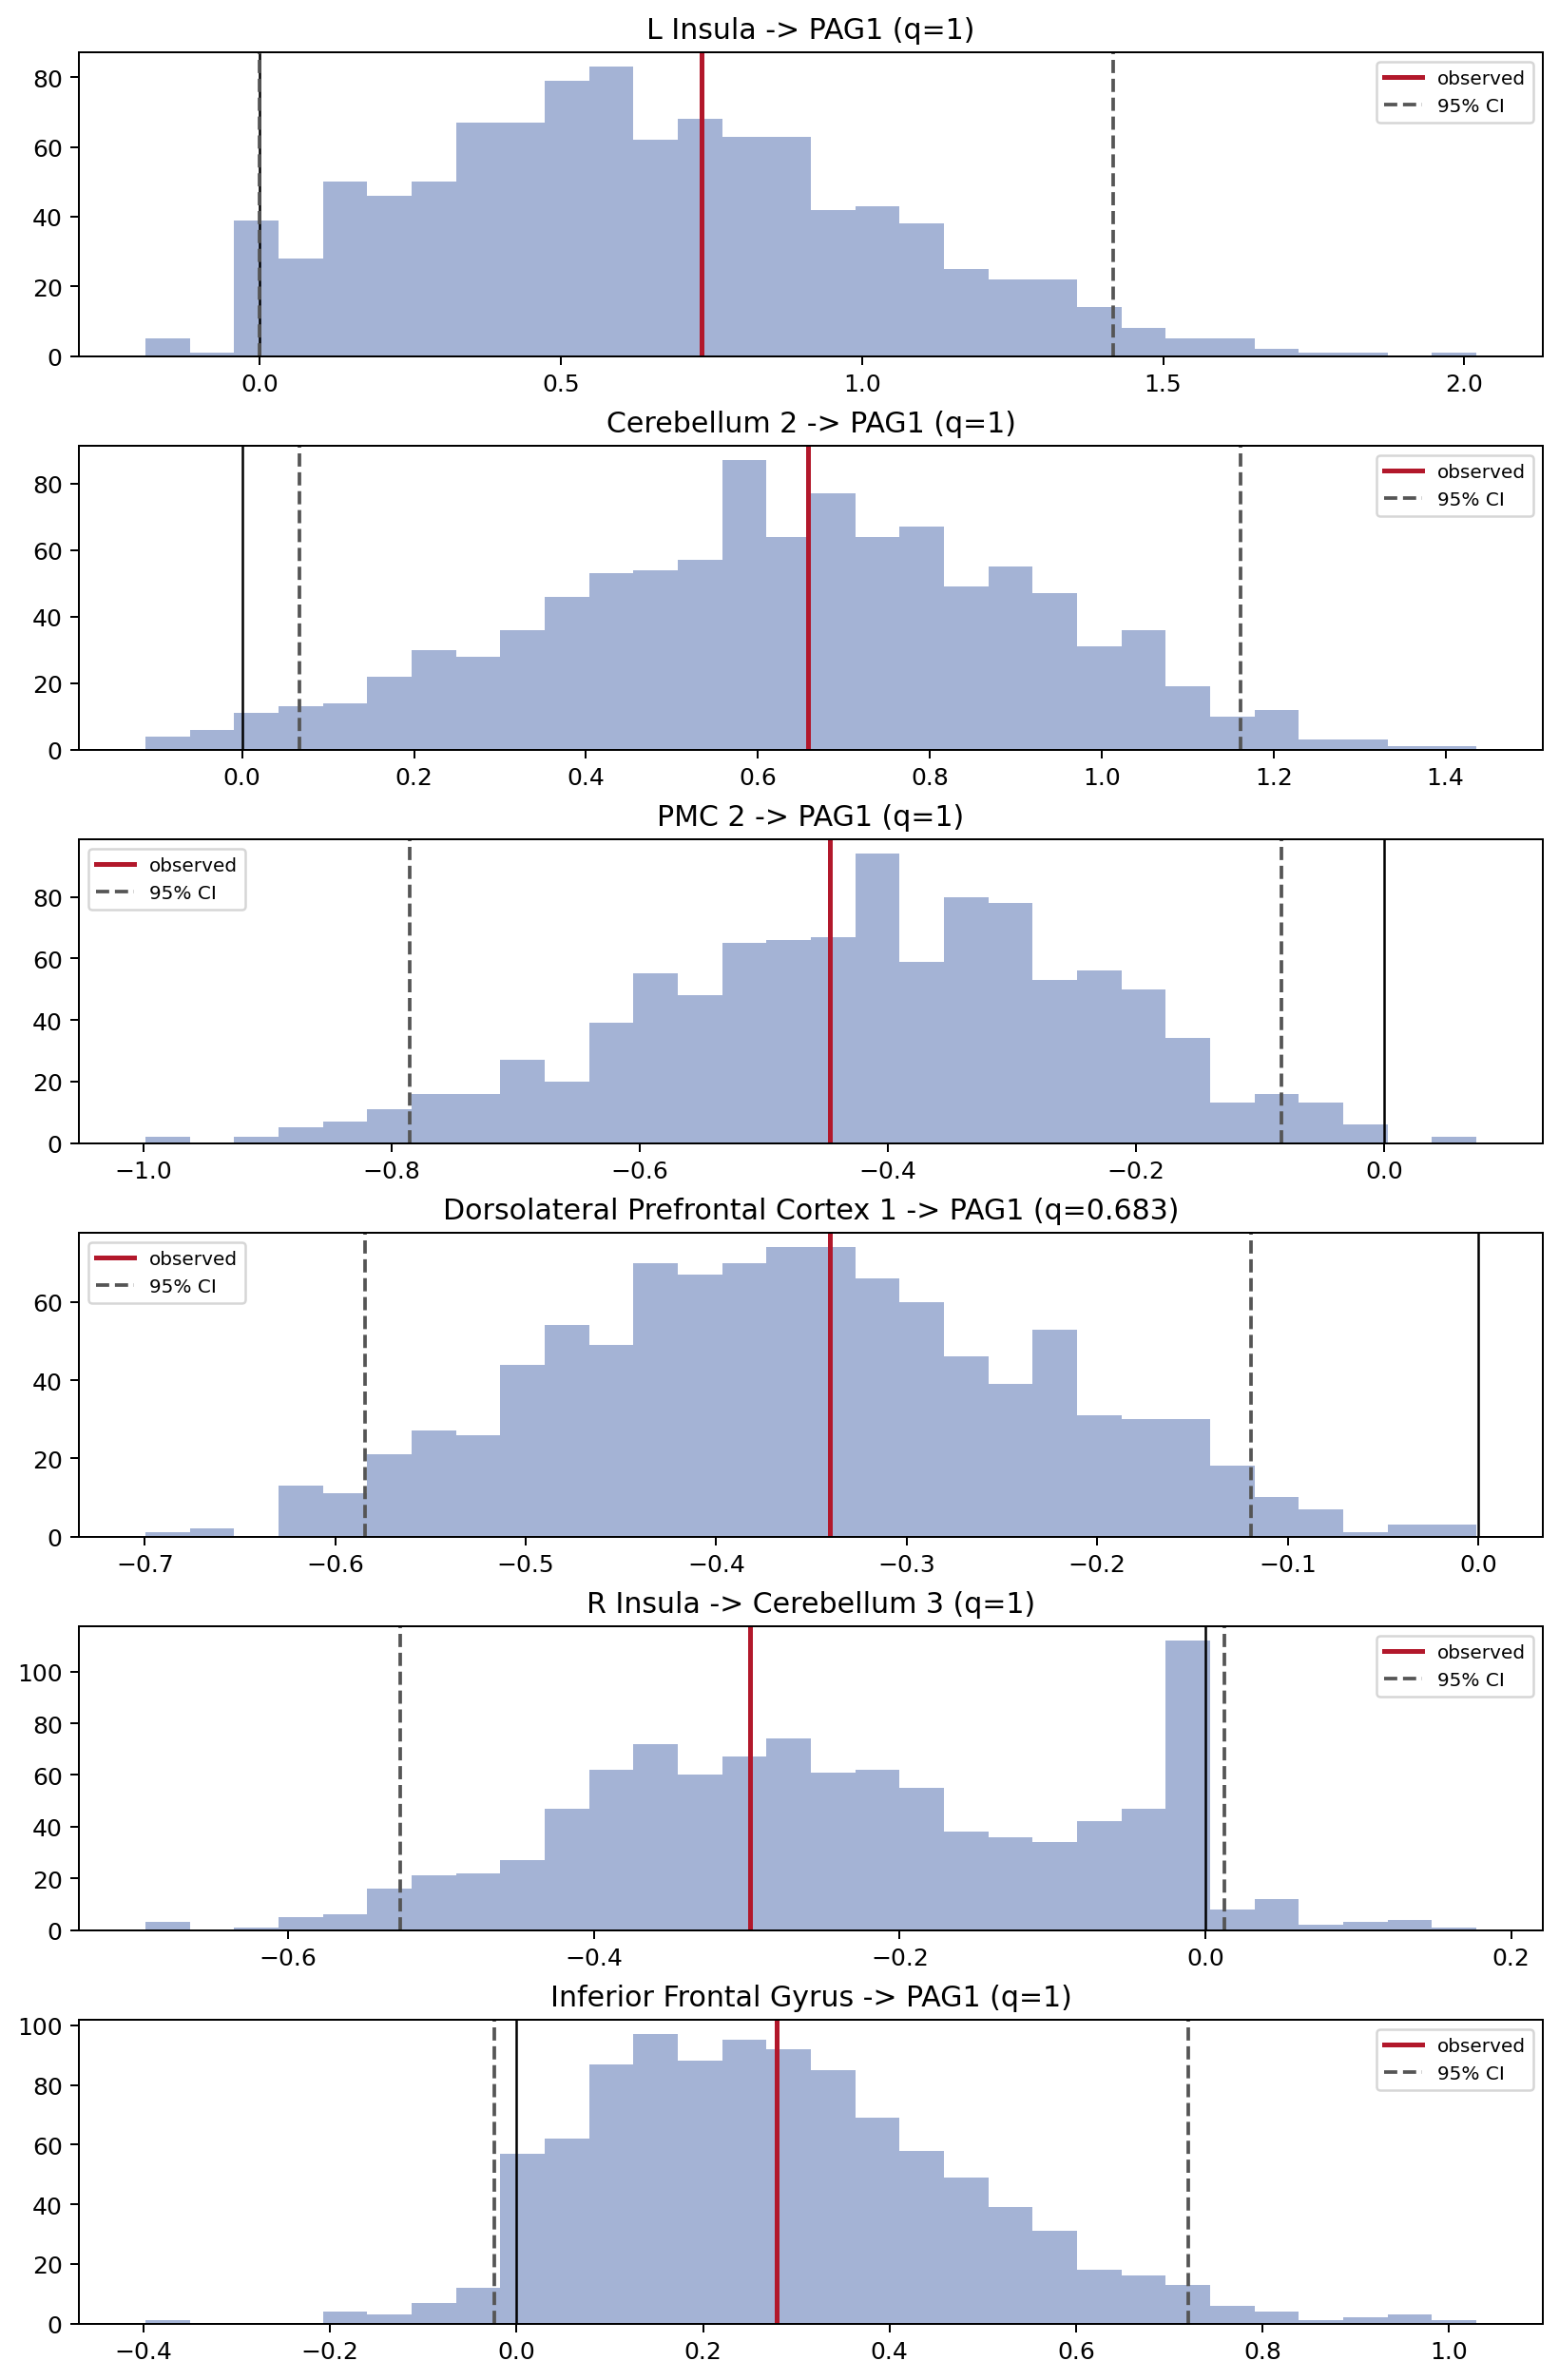

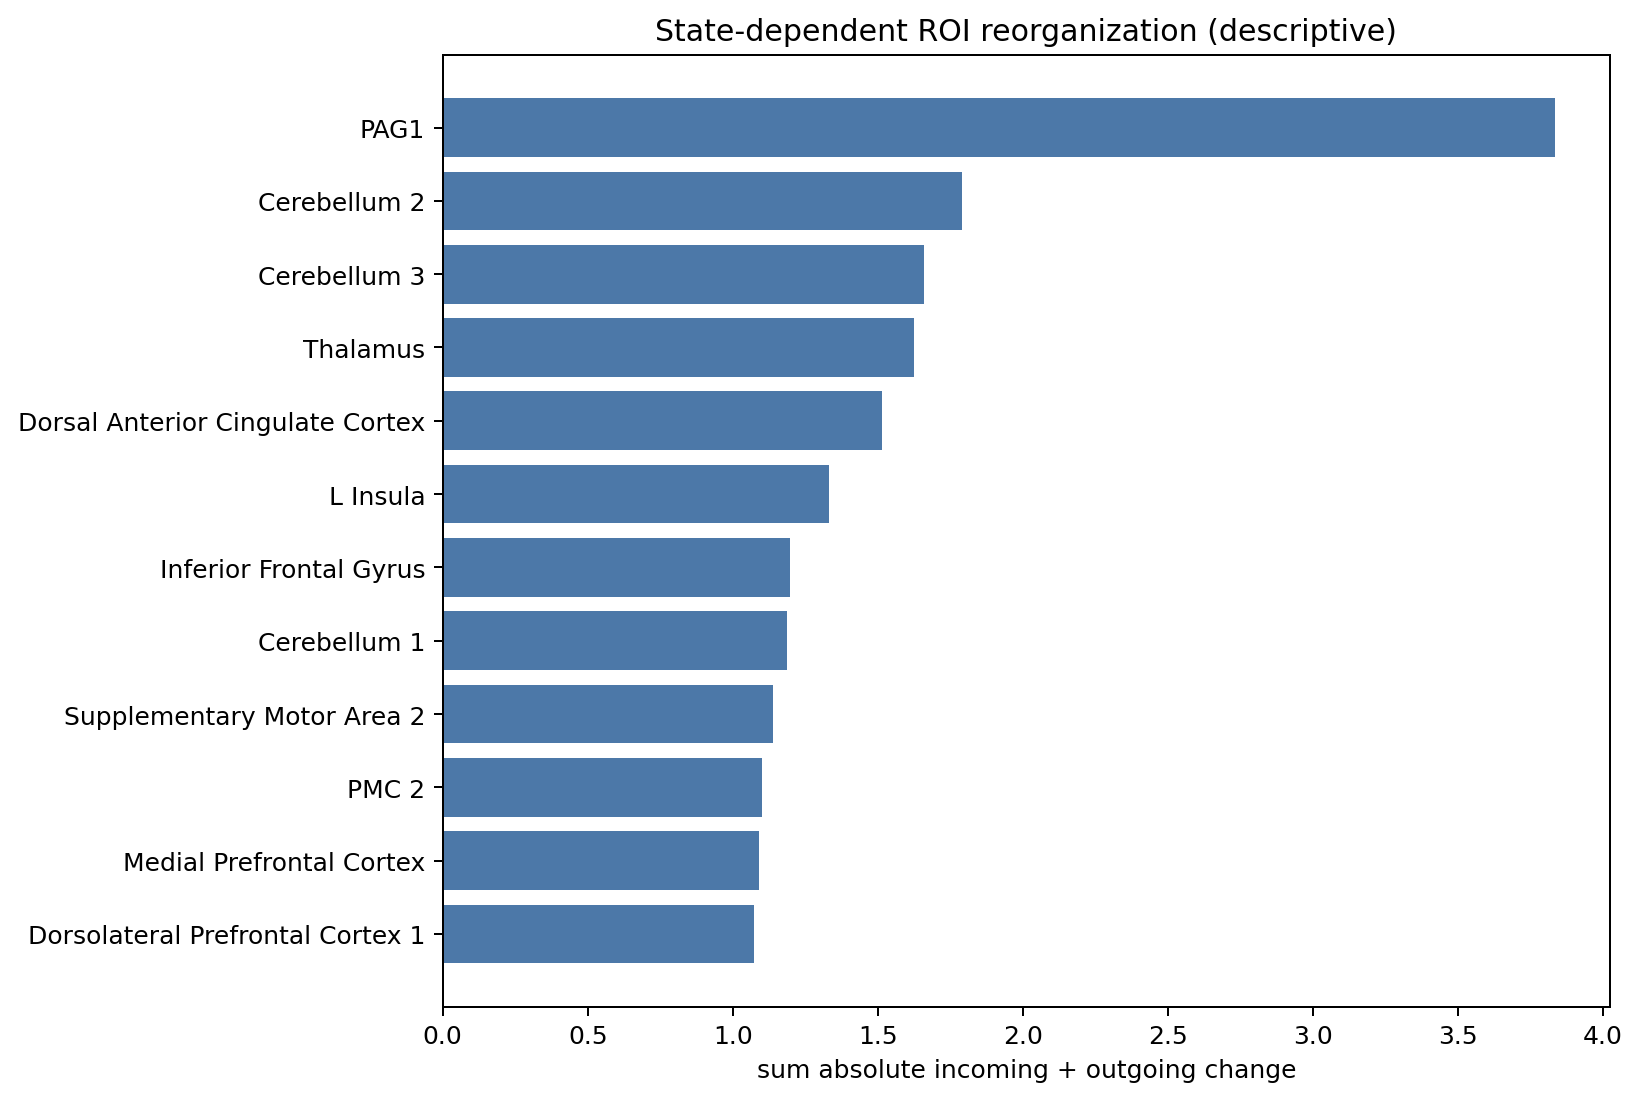

In [18]:
bootstrap_dir=INFERENCE_OUTPUT/'case2_bootstrap'
edge_csv=INFERENCE_OUTPUT/'case2_bootstrap_edge_results.csv'
if edge_csv.exists():
    edge_results=pd.read_csv(edge_csv)
    nominal_edges = edge_results[
        edge_results.p_boot < .05
    ].sort_values("p_boot")

    fdr_edges = edge_results[
        edge_results.q_fdr < .05
    ].sort_values("q_fdr")

    print({
        "off_diagonal_tests": len(edge_results),
        "nominal_p_lt_0.05": len(nominal_edges),
        "fdr_q_lt_0.05": len(fdr_edges),
    })
    print("Nominal uncorrected edges:")
    display(nominal_edges)

    print("BH-FDR supported edges:")
    display(
        fdr_edges
        if len(fdr_edges)
        else pd.DataFrame({
            "result": ["No edge survives BH-FDR at q < 0.05."]
        })
    )

    nodes=pd.read_csv(INFERENCE_OUTPUT/'case2_node_reorganization.csv'); display(nodes.head(12))
    for filename in (
        'case2_bootstrap_delta_significance.png',
        'case2_bootstrap_nominal_edge_intervals.png',
        'case2_bootstrap_control_significance.png',
        'case2_bootstrap_sdv_significance.png',
        'static_graph_comparison.png',
        'case2_bootstrap_edge_stability.png',
        'case2_bootstrap_edge_intervals.png',
        'case2_bootstrap_key_edge_distributions.png',
        'case2_node_reorganization.png',
    ):
        path = INFERENCE_OUTPUT / filename
        if path.exists():
            display(Image(filename=str(path)))
else:
    print('Cached bootstrap inference not found. Launch/resume it with --bootstrap-reps and --bootstrap-resume; the notebook will not refit it automatically.')

### Sex Analysis

In [ ]:
plot_anatomical_directed_difference(
    interaction,
    control.roi_xyz,
    display,
    sex_out / "sex_interaction_anatomical.png",
    view="coronal",
    min_abs_change=args.edge_threshold,
    title=(
        "Sex × Bladder-State Interaction\n"
        "(Female SDV − Control) − (Male SDV − Control)"
    ),
    positive_color="darkorange",
    negative_color="purple",
    positive_label="Larger / more positive SDV change in women",
    negative_label="Larger / more positive SDV change in men",
    magnitude_label=r"Arrow width $\propto |\Delta W_{Female}-\Delta W_{Male}|$",
)

In [ ]:
from pathlib import Path
from IPython.display import display, Image, Markdown

SEX_RESULTS = RESULTS_DIR / "sex_analysis"

sex_figures = [
    (
        "Sex-stratified directed networks",
        "Male and female Control/SDV networks and their within-sex "
        "SDV − Control directed changes. Thick edges indicate "
        "uncorrected bootstrap p < 0.05 when bootstrap results are available.",
        SEX_RESULTS / "sex_static_dag_comparison.png",
    ),
    (
        "Sex-stratified state-change heatmaps",
        "Male and female SDV − Control changes followed by the "
        "sex × bladder-state interaction "
        "(Female ΔW − Male ΔW). Open circles indicate uncorrected "
        "bootstrap p < 0.05; stars indicate BH-FDR q < 0.05.",
        SEX_RESULTS / "sex_state_change_heatmaps.png",
    ),
    (
        "ROI-level reorganization by sex",
        "Total absolute incoming plus outgoing directed-weight change "
        "between Control and SDV.",
        SEX_RESULTS / "sex_node_reorganization.png",
    ),
    (
        "Anatomical sex × bladder-state interaction",
        "Orange edges indicate a larger or more positive SDV − Control "
        "change in women; purple edges indicate a larger or more positive "
        "change in men. Arrow width is proportional to the absolute "
        "Female ΔW − Male ΔW interaction.",
        SEX_RESULTS / "sex_interaction_anatomical.png",
    ),
    (
        "Male anatomical SDV − Control change",
        "Red indicates increases at SDV and blue indicates decreases.",
        SEX_RESULTS / "male_sdv_control_anatomical.png",
    ),
    (
        "Female anatomical SDV − Control change",
        "Red indicates increases at SDV and blue indicates decreases.",
        SEX_RESULTS / "female_sdv_control_anatomical.png",
    ),
]

for title, description, path in sex_figures:
    display(Markdown(f"### {title}\n{description}"))
    if path.exists():
        display(Image(filename=str(path)))
    else:
        display(Markdown(f"*Not generated yet: `{path.name}`*"))

## 7. Case 4 — time-series latent-confounded causal model

In [4]:
X0c,Xlc,_=build_multisubject_lagged_data(control,P); X0s,Xls,_=build_multisubject_lagged_data(sdv,P)
print(X0c.shape,Xlc.shape,X0s.shape,Xls.shape)
dynamic_control=fit_dynamic_latent([control.timeseries[s] for s in control.subject_ids],P,**DYNAMIC)
dynamic_sdv=fit_dynamic_latent([sdv.timeseries[s] for s in sdv.subject_ids],P,**DYNAMIC)
print(dynamic_control.diagnostics); print(dynamic_sdv.diagnostics)

(3608, 19) (1, 3608, 19) (3609, 19) (1, 3609, 19)
{'objective': 22.70832083147784, 'fit_loss': 15.185322655620173, 'sparse_0_penalty': 0.33764195943555503, 'sparse_lag_penalty': 0.6142462720959148, 'latent_penalty': 6.5707002214172325, 'h_raw': 5.783416412441511e-09, 'h_thresholded': 0.0, 'rho': 10000000000000.0, 'peak_rho': 10000000000000.0, 'alpha': 99761.52412670085, 'outer_iterations': 11, 'total_inner_iterations': 5682, 'total_function_evaluations': 5781, 'optimizer_success': True, 'optimizer_status': 0, 'optimizer_message': 'CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH', 'gradient_norm': 15.66422773326918, 'history': [{'outer_iter': 1, 'rho': 1.0, 'alpha': 0.0, 'h': 0.10795886608298488, 'fit_loss': 12.502450751164925, 'sparse_0_penalty': 0.7135172157892605, 'sparse_lag_penalty': 0.5786393300689944, 'latent_penalty': 8.258426802036062, 'augmented_objective': 22.058861657442204, 'optimizer_success': True, 'optimizer_nit': 484, 'optimizer_nfev': 485, 'Z_fro_norm': 20.3203945

## 8. Case 4 — Control vs SDV comparison

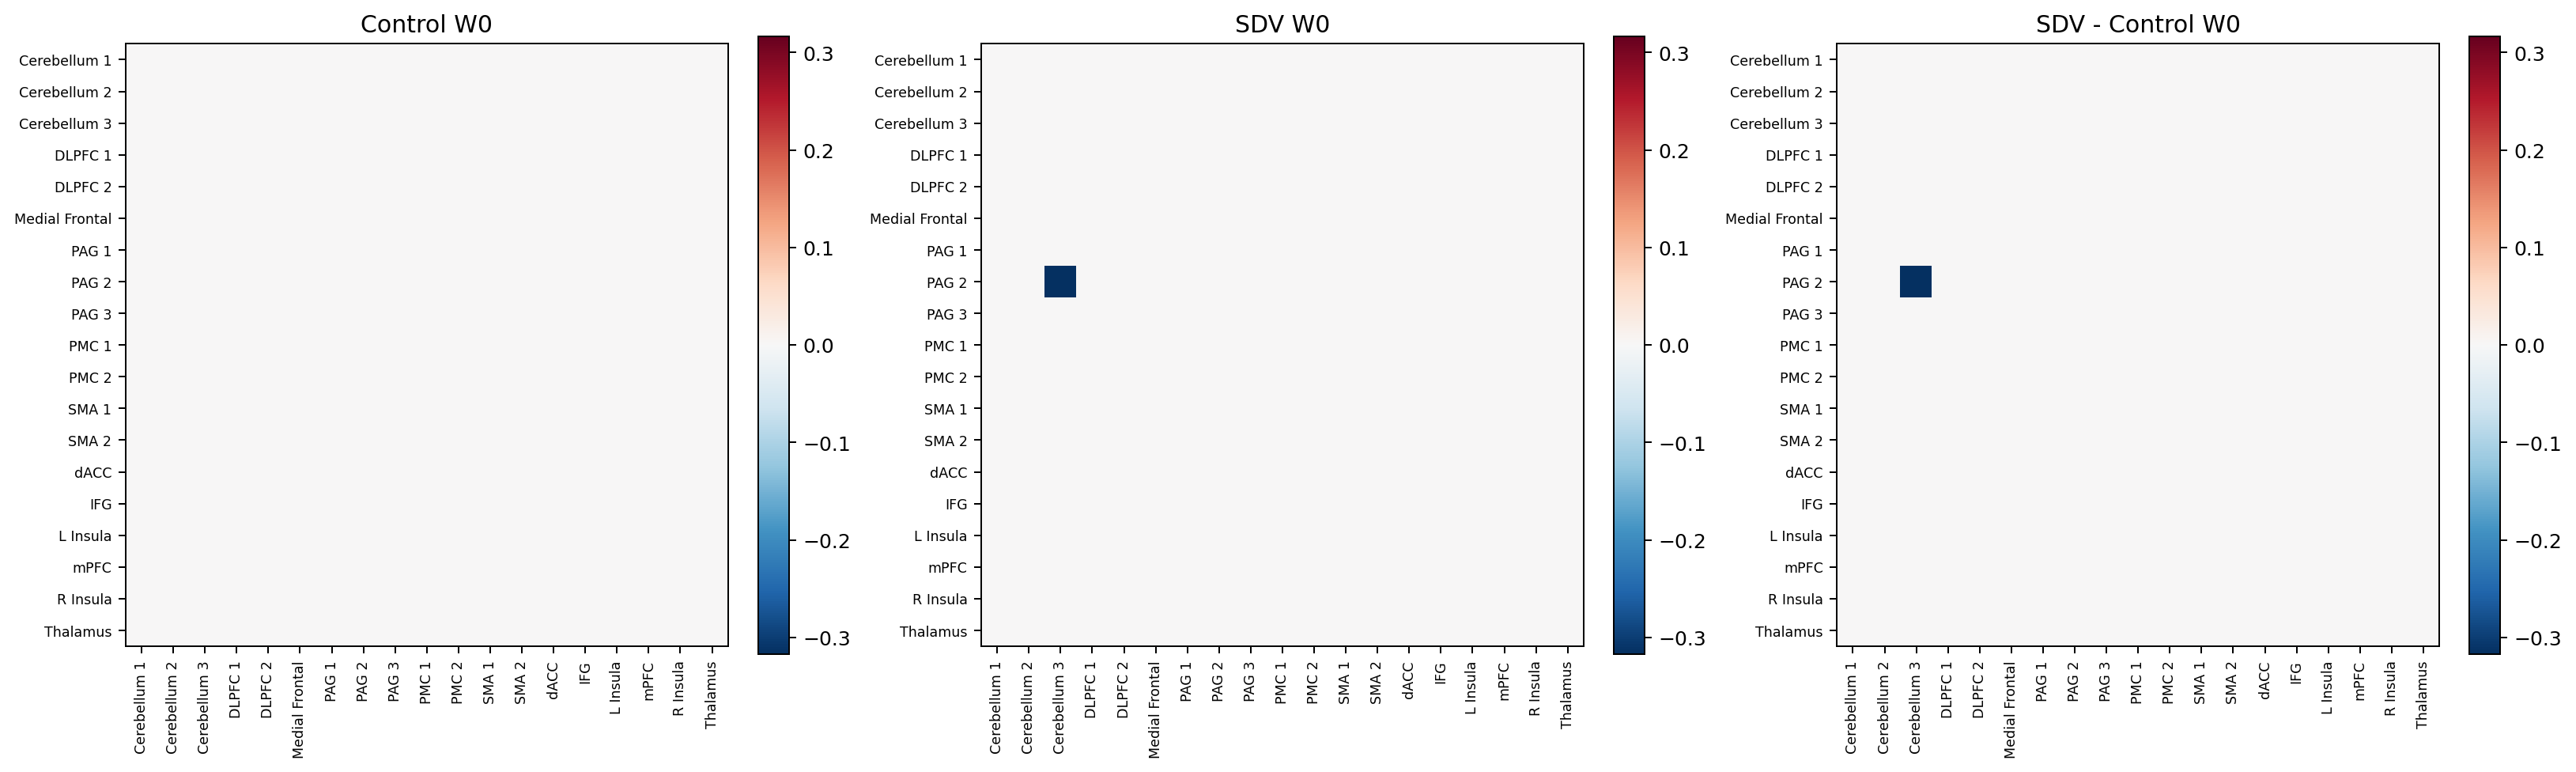

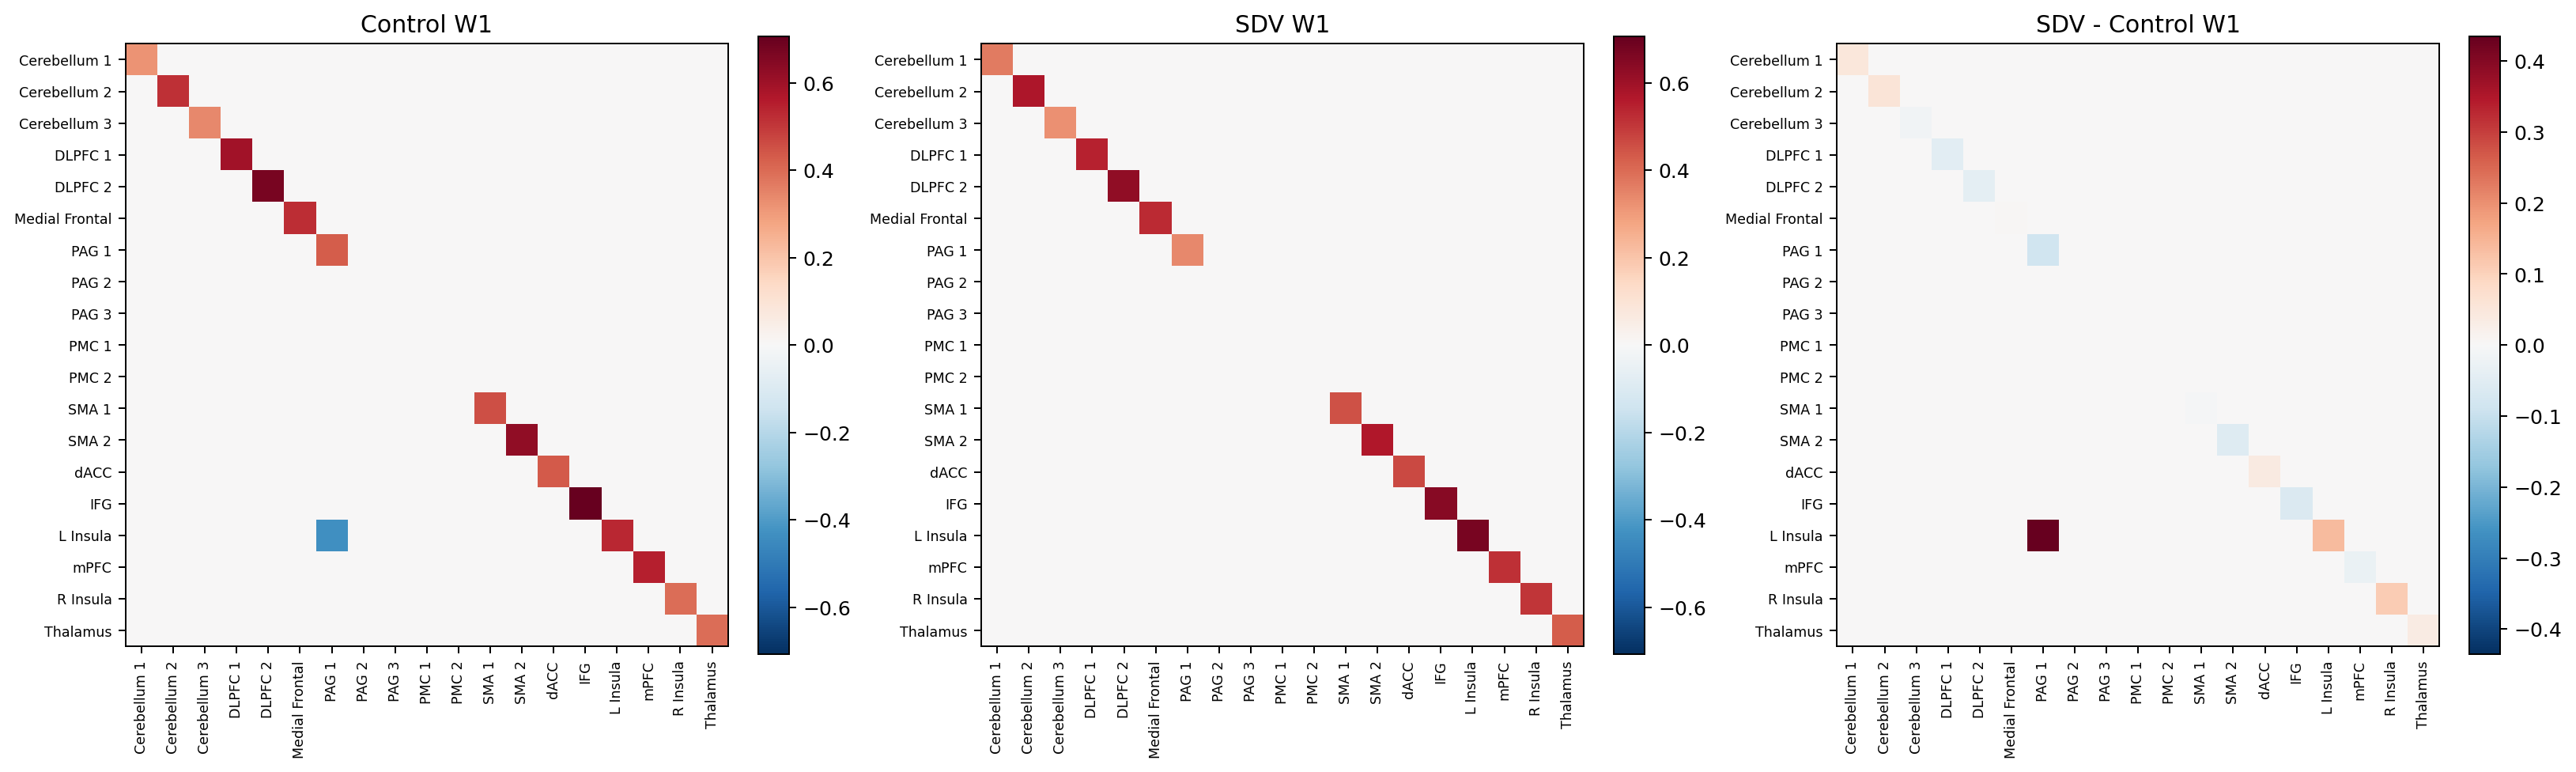

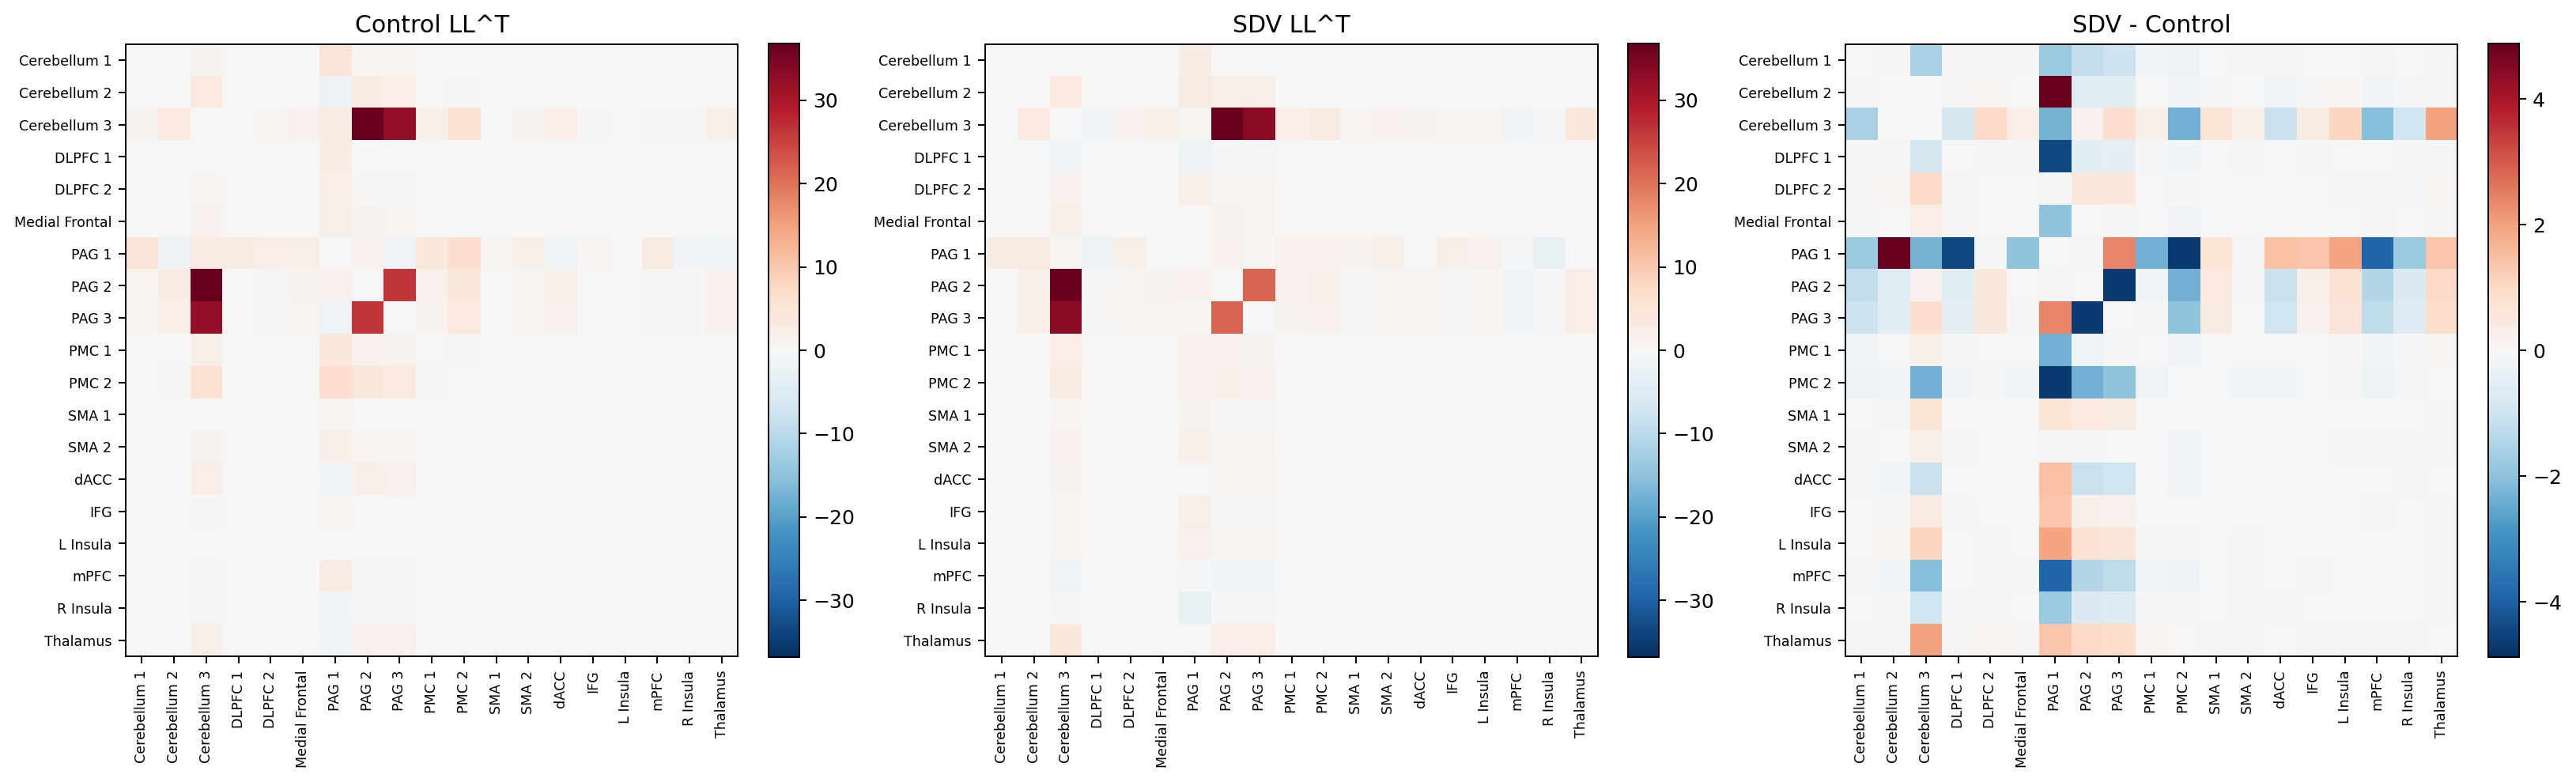

In [5]:
plot_matrix_comparison(dynamic_control.W0,dynamic_sdv.W0,DISPLAY,('Control W0','SDV W0','SDV - Control W0'),OUTPUT/'dynamic_W0_comparison.png')
display(Image(filename=str(OUTPUT/'dynamic_W0_comparison.png')))
for tau in range(P):
    filename=OUTPUT/f'dynamic_Wlag{tau+1}_comparison.png'
    plot_matrix_comparison(dynamic_control.W_lags[tau],dynamic_sdv.W_lags[tau],DISPLAY,(f'Control W{tau+1}',f'SDV W{tau+1}',f'SDV - Control W{tau+1}'),filename)
    display(Image(filename=str(filename)))
DS_control=latent_similarity(dynamic_control); DS_sdv=latent_similarity(dynamic_sdv)
plot_matrix_comparison(DS_control,DS_sdv,DISPLAY,('Control LL^T','SDV LL^T','SDV - Control'),OUTPUT/'dynamic_latent_comparison.png',True)
display(Image(filename=str(OUTPUT/'dynamic_latent_comparison.png')))

2 rows same figure plot

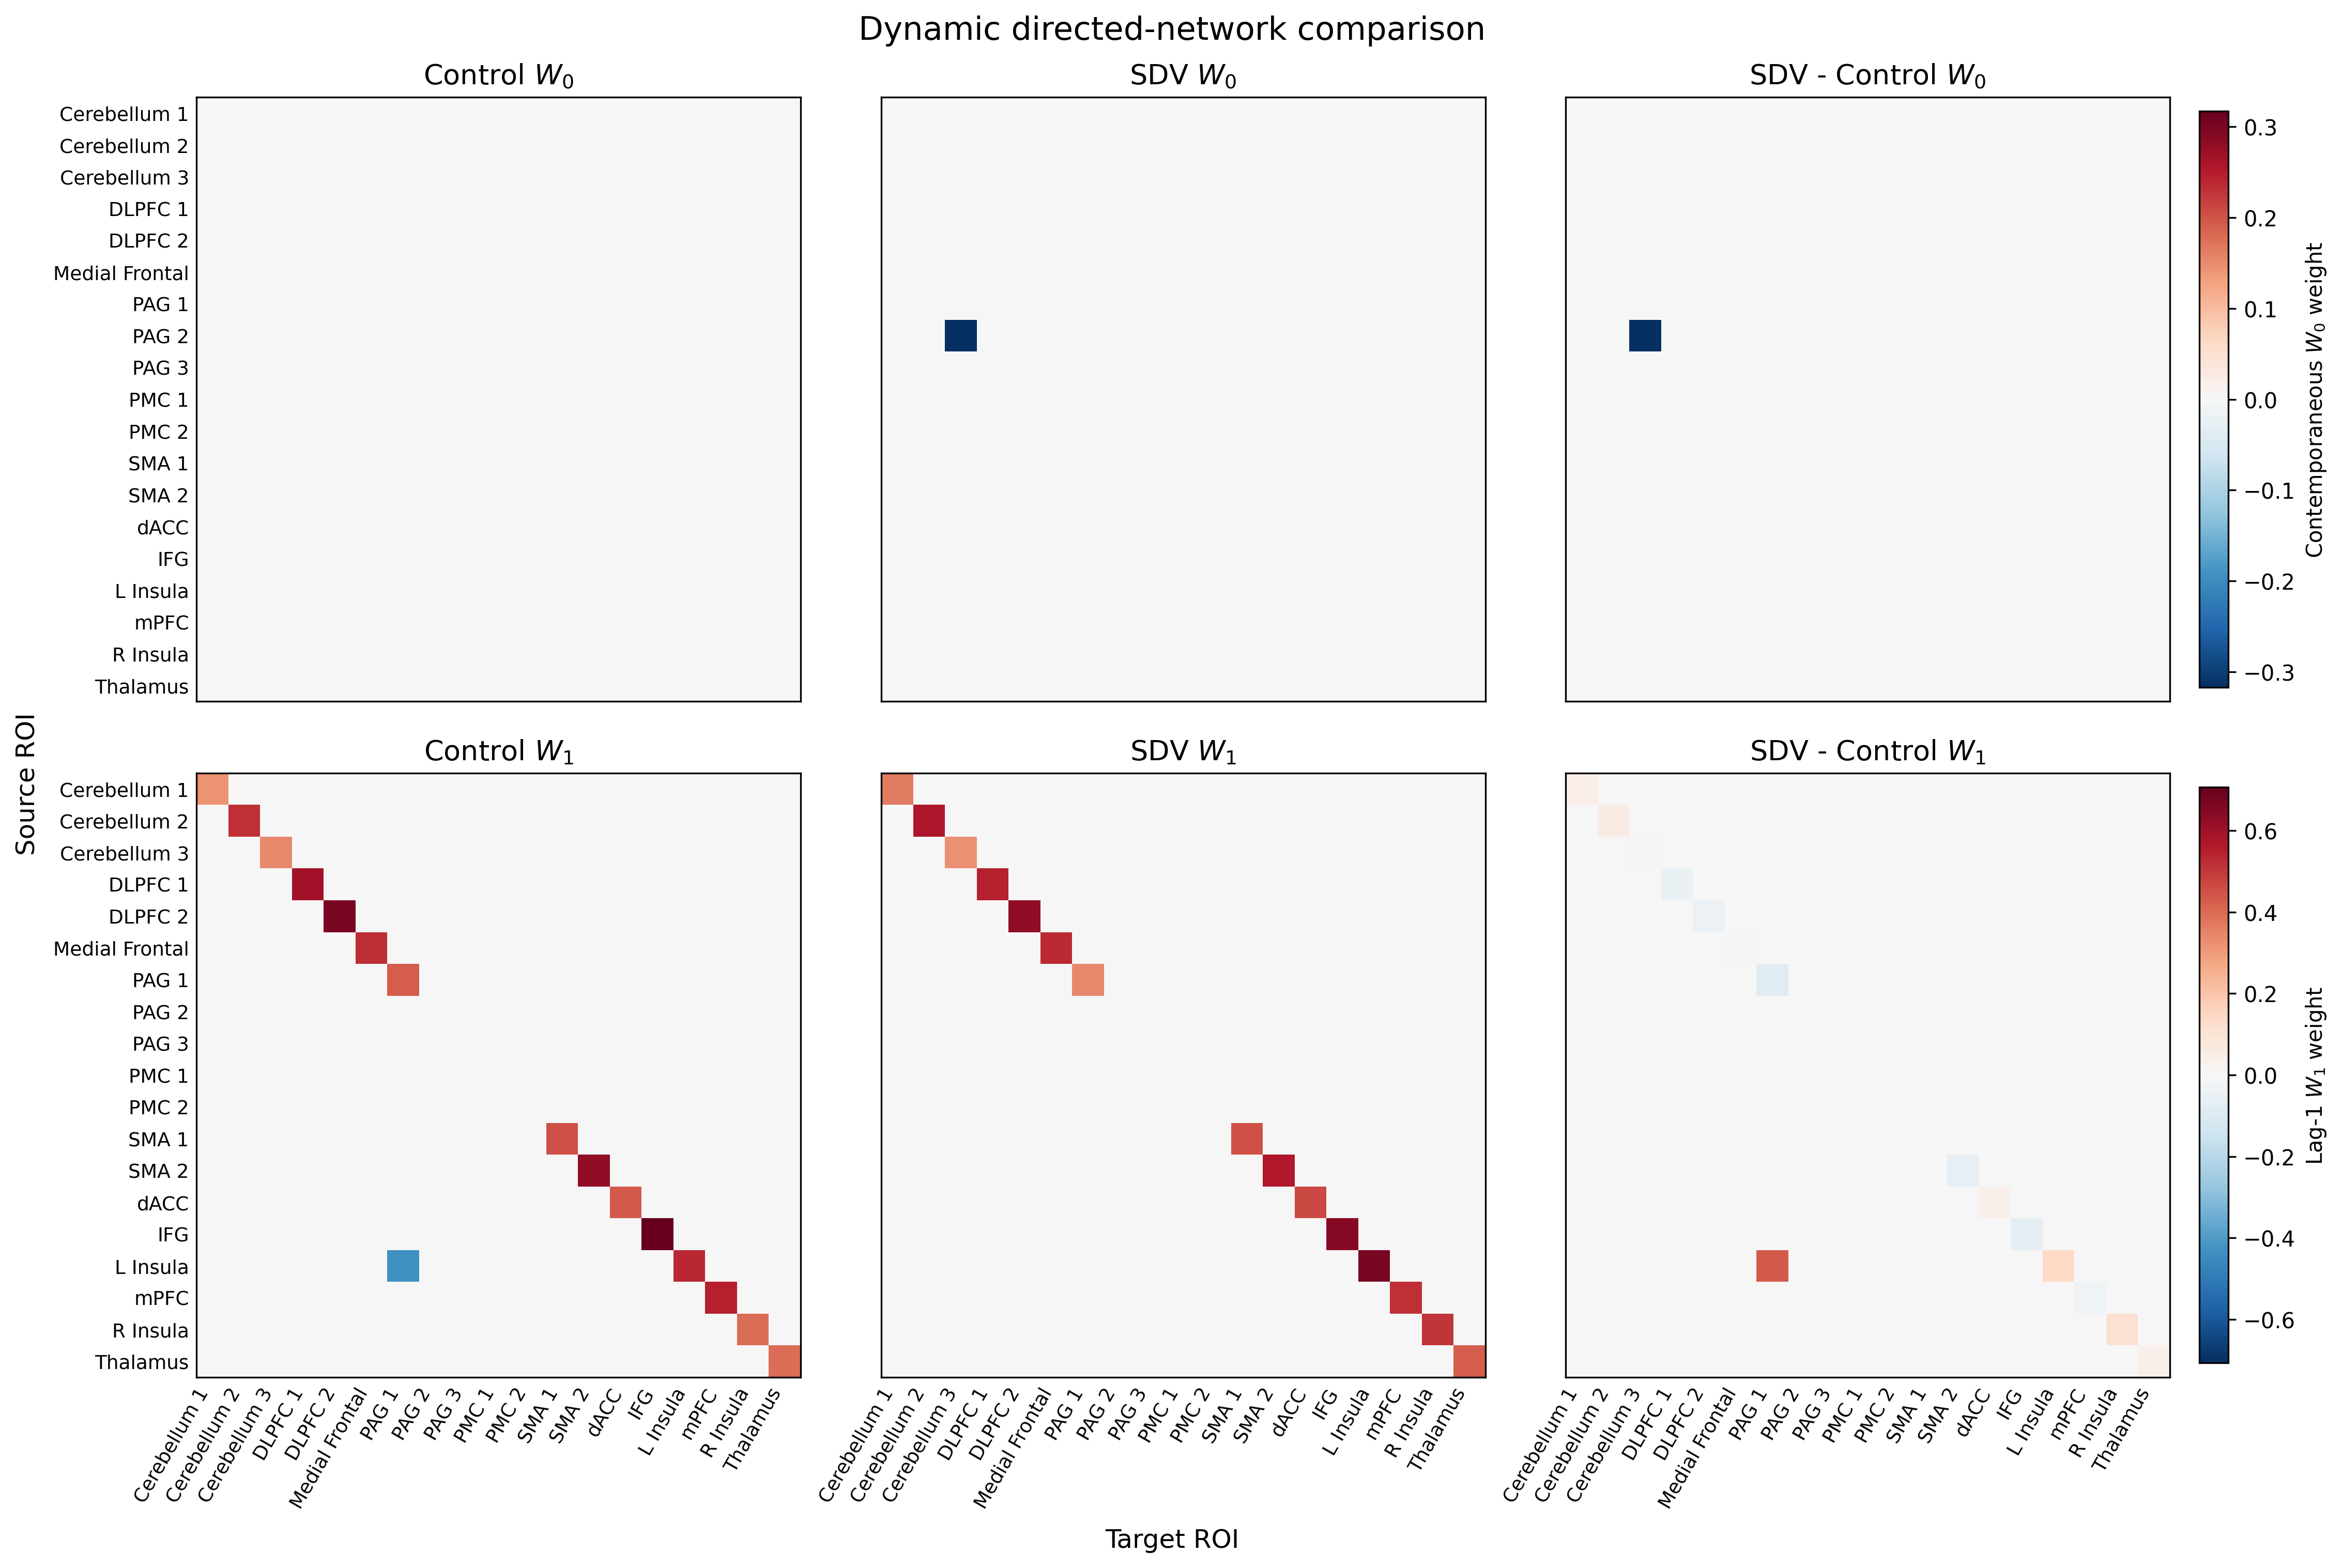

In [15]:
from causal_opt.fmri import plot_dynamic_matrix_comparison

for tau in range(P):
    if P != 1:
        raise ValueError(
            f"The two-row Figure 4 expects P=1, but the fitted model uses P={P}."
        )

    dynamic_figure_path = OUTPUT / "dynamic_W0_W1_comparison.png"

    plot_dynamic_matrix_comparison(
        W0_control=dynamic_control.W0,
        W0_sdv=dynamic_sdv.W0,
        W1_control=dynamic_control.W_lags[0],
        W1_sdv=dynamic_sdv.W_lags[0],
        display_threshold=EDGE_THRESHOLD,
        roi_labels=DISPLAY,
        output_path=dynamic_figure_path,
    )

    display(Image(filename=str(dynamic_figure_path)))

## 9. Initial observations
Ranked changes below are descriptive model outputs, not inferential statistics or biological conclusions.

In [9]:
print('Static directed changes:',top_matrix_changes(static_control.W0,static_sdv.W0,DISPLAY))
print('Static latent changes:',top_matrix_changes(S_control,S_sdv,DISPLAY))
print('Dynamic W0 changes:',top_matrix_changes(dynamic_control.W0,dynamic_sdv.W0,DISPLAY))
for tau in range(P): print(f'Lag {tau+1} changes:',top_matrix_changes(dynamic_control.W_lags[tau],dynamic_sdv.W_lags[tau],DISPLAY))

Static directed changes: [{'source': 'BN19-16', 'target': 'BN19-07', 'control': -0.7347268932121247, 'sdv': 0.0, 'change': 0.7347268932121247}, {'source': 'BN19-18', 'target': 'BN19-07', 'control': 0.0, 'sdv': -0.4753200556122066, 'change': -0.4753200556122066}, {'source': 'BN19-11', 'target': 'BN19-07', 'control': 0.43654794241042033, 'sdv': 0.0, 'change': -0.43654794241042033}, {'source': 'BN19-02', 'target': 'BN19-07', 'control': 0.0, 'sdv': 0.3847941438628794, 'change': 0.3847941438628794}, {'source': 'BN19-13', 'target': 'BN19-01', 'control': 0.0, 'sdv': 0.3351937621330644, 'change': 0.3351937621330644}, {'source': 'BN19-06', 'target': 'BN19-13', 'control': 0.3233966920869517, 'sdv': 0.39907821180424463, 'change': 0.07568151971729292}, {'source': 'BN19-06', 'target': 'BN19-12', 'control': 0.4213253638453382, 'sdv': 0.4610018028746211, 'change': 0.03967643902928292}, {'source': 'BN19-12', 'target': 'BN19-13', 'control': 0.5303398629856818, 'sdv': 0.5068297352189386, 'change': -0.02